## AI 모델 개발 15회차 1차 팀프로젝트 - NASA Turbofan Jet Engine Data Set 터보엔진 유지보전 문제_FD001

[데이터셋 개요]
이 데이터셋은 NASA의 C-MAPSS(Commercial Modular Aero-Propulsion System Simulation)
시뮬레이터를 사용하여 생성된 터보팬 엔진의 열화(Degradation) 데이터입니다.

데이터는 여러 개의 다변량 시계열(Multivariate Time Series)로 구성되어 있습니다.
데이터셋은 학습(Training) 세트와 테스트(Test) 세트로 나뉩니다.
각 시계열 데이터는 서로 다른 엔진(Unit)에서 얻은 데이터이며, 동일한 유형의 엔진들로 간주할 수 있습니다.

[실험 시나리오]
1. 초기 상태: 각 엔진은 정상 상태에서 작동을 시작합니다.
   - 단, 사용자에게는 알려지지 않은 수준의 초기 마모(Initial Wear)와 제조 공차(Variation)가 존재합니다.
     (이는 결함이 아닌 정상적인 범주입니다.)
2. 고장 진행: 어느 시점부터 결함(Fault)이 발생하여 시간이 지날수록 상태가 악화됩니다.
3. 데이터 범위:
   - 학습 세트 (Train): 결함 발생부터 시스템 고장(Failure) 시점까지의 모든 데이터가 포함됩니다.
   - 테스트 세트 (Test): 고장 발생 전 임의의 시점에서 데이터 기록이 중단됩니다.

[목표 (Objective)]
테스트 세트에 포함된 각 엔진의 **잔여 유효 수명(RUL: Remaining Useful Life)**을 예측하는 것입니다.
즉, 테스트 데이터가 끊긴 시점으로부터 엔진이 고장 날 때까지 몇 사이클(Cycle)이 더 남았는지 맞히는 것이 목표입니다.

> FD001 (Train: train_FD001.txt / Test: test_FD001.txt / RUL: RUL_FD001.txt)
   - 학습 엔진 수: 100개
   - 테스트 엔진 수: 100개
   - 운전 조건 (Conditions): 1가지 (해수면 - Sea Level)
   - 고장 모드 (Fault Modes): 1가지 (HPC 열화 - HPC Degradation)


> 여러 셀에서 사용되는 함수는 먼저 정의하고 시작한다. 코드 오류 방지

## 1. 라이브러리 및 데이터 로드

In [1]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

이 문제는 초기 마모와 계측 노이즈를 반영한 노이즈가 매우 심한 데이터셋

## 시계열 데이터 이기 때문에 모델이 시간의 흐름을 반영하기 위해 rolling window 방식 채용 
노이즈에 강해진다, 고장 직전에 분산이 커지면 더 빨리 감지할수 있어 정확도가 올라간다. 단, 결측치가 있는경우 부적합

### 윈도우 사이즈는 5(단기 추세)와 20(장기 추세) 모두 사용 (사이즈 -1개 만큼 앞에서 제거)
5 : 노이즈가 적당히 제거, 데이터 손실 적음, 변화에 민감(갑자기 고장에 적합)
20 : 노이즈가 크게 제거, 데이터 손실 크다, 변화에 둔감(서서히 고장에 적합)


In [2]:
# 노이즈 제거 함수 정의

from scipy.signal import savgol_filter

def add_advanced_features(df):
    """
    [기능]
    1. Savitzky-Golay 필터: 원본 센서의 노이즈를 매끄럽게 제거 (Technique B)
    2. EMA(지수이동평균): 최신 트렌드를 빠르게 반영 (Technique A)
    3. Rolling Window (5, 20): 기존의 단기/장기 트렌드 정보 유지
    """
    df_proc = df.copy()
    
    # 적용 대상: 'sensor'가 포함되거나 단위 '['가 붙은 컬럼
    # (주의: unit_number, time_in_cycles, RUL 등은 제외됨)
    target_cols = [c for c in df_proc.columns if ('sensor' in c or '[' in c) and c not in ['unit_number', 'time_in_cycles', 'RUL']]
    
    print(f"   👉 Advanced Feature 적용 대상: {len(target_cols)}개 컬럼")
    
    for col in target_cols:
        grouped = df_proc.groupby('unit_number')[col]
        
        # [Technique B] Savitzky-Golay 필터 (노이즈 제거)
        # 데이터가 충분할 때만 적용 (window 11)
        try:
            df_proc[col] = grouped.transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except:
            pass 

        # [Technique A] EMA (지수 이동 평균, span=20)
        # 늦은 예측 방지에 탁월함
        df_proc[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
        
        # [기존 기능] Rolling Window 5 & 20
        df_proc[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_5"]  = grouped.rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
        df_proc[f"{col}_mean_20"] = grouped.rolling(window=20, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_20"] = grouped.rolling(window=20, min_periods=1).std().reset_index(0, drop=True)
        
    return df_proc

In [3]:
# kaggle에서 데이터 가져오기

%pip install kaggle==1.8.0

from dotenv import load_dotenv
load_dotenv()

!kaggle datasets download behrad3d/nasa-cmaps

Note: you may need to restart the kernel to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps
License(s): CC0-1.0
nasa-cmaps.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
# 데이터 가져오기
import os
HOME = os.getcwd()
zipPath = os.path.join(HOME, "nasa-cmaps.zip")
targetPath = os.path.join(HOME, 'data')

from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)


In [5]:
parent_path = "C:/Users/user/github/EST_15th_NASA/한지형/data/CMaps"

FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])


Train path: C:/Users/user/github/EST_15th_NASA/한지형/data/CMaps\train_FD001.txt


In [6]:
train_df.head()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


# labelling

In [7]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


In [8]:
train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Ps30[psi],NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


# Feature Engineering

In [9]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ? 
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df.head()


,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,Fan.PR[-],LPC.TR[-],HPC.TR[-],OPR[-],Wf[pph],Wa36[lbm/s],W24[lbm/s],W15[lbm/s],W2[lbm/s],WfP3C[pph/psi]
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,1.478112,1.237434,2.476863,37.917921,24763.2002,229.288891,291.767891,2456.539756,2748.307647,47.47
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,1.478112,1.238070,2.478891,37.876197,24803.0772,229.658122,292.081722,2462.774665,2754.856388,47.49
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,1.478112,1.238456,2.472157,37.911081,24694.7934,228.655494,290.949694,2449.156338,2740.106032,47.27
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,1.478112,1.238456,2.464062,37.924077,24642.3918,228.170294,290.424194,2430.327744,2720.751938,47.13
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,1.478112,1.238495,2.464078,37.893297,24689.1432,228.603178,290.907578,2452.176336,2743.083914,47.28


In [10]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df


,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%)
0,unit_number,int64,20631,0,0.0
1,time_in_cycles,int64,20631,0,0.0
2,Alt[kft],float64,20631,0,0.0
3,Mn[-],float64,20631,0,0.0
4,TLA[deg],float64,20631,0,0.0
5,T2[R],float64,20631,0,0.0
6,T24[R],float64,20631,0,0.0
7,T30[R],float64,20631,0,0.0
8,T50[R],float64,20631,0,0.0
9,P2[psi],float64,20631,0,0.0


## RUL Clipping (초기 건강한 구간을 특정 RUL로 고정) 
학습 혼란 방지해 정확도 상승   
나중에 변곡점 방식이나 분류 방식 등으로 응용 가능   
변곡점 방식 : 라이브러리의 kneed를 사용 또는 CUSUM 방식으로 누적 합계가 관리 한계선을 넘어가는 지점을 찾기 단, 변곡점을 잘못 찾으면 성능이 떨어짐.   
분류 모델 방식 : "정상(Healthy)" vs "고장 진행 중(Degrading)" 두 그룹으로 나눠 이진 분류 후 다른 RUL 지점의 데이터를 분류 모델이 구분해 낼 수 있는 최적 clipping 포인트 찾는 방식    
하이퍼파라미터 튜닝 방식 : 아래 적용    

## RUL clipping을 초기에 해야하는 이유 
* RUL Clipping 전 (원본 데이터) : RUL이 사이클이 진행되면서 줄어들면서 센서사이 상관계수가 낮게 찍힘
* RUL Clipping 후 (원본 데이터) : RUL이 고정되어 센서 사이의 관계성이 더 제대로 파악되어 상관계수가 높아짐.


In [11]:
# 보통 RUL이 125보다 크면 모두 125로 고정 (Piecewise Linear RUL)
# 이유: 초기 건강한 구간에서의 불필요한 학습 혼란 방지
# GridSearch 를 이용해 [100, 110, 120, 125, 130, 140, 150] 중에 최적 클립 구간 찾기


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

# RUL 컬럼 생성 
max_cycle = train_df.groupby('unit_number')['time_in_cycles'].transform('max')
train_df['RUL'] = max_cycle - train_df['time_in_cycles']
print("RUL 컬럼 생성 완료!")

# ---------------------------------------------------------
# [Step 1] Grid Search로 최적의 RUL Clipping 포인트 탐색
# ---------------------------------------------------------
print("🔎 최적의 RUL 상한선(Clipping Limit) 탐색을 시작합니다...")

# 1. 탐색할 후보군 설정 (100 ~ 140 사이)
candidate_limits = [100, 110, 120, 125, 130, 140, 150]
best_rmse = float('inf')
best_limit = 125 # 기본값 (혹시 탐색 실패 시 안전장치)

# 문자열(object) 컬럼은 제외하고, 오직 숫자형(number) 컬럼만 선택합니다.
numeric_cols = train_df.select_dtypes(include=[np.number]).columns

# 2. 실험을 위한 임시 데이터 준비
# (현재 train_df에서 모델링에 사용할 컬럼만 뽑습니다)
features = [c for c in numeric_cols if c not in ['unit_number', 'time_in_cycles', 'RUL']]
groups = train_df['unit_number']

# 3. 반복문으로 후보군 테스트
for limit in candidate_limits:
    # (1) RUL Clipping 적용 (임시)
    # 원본 train_df는 건드리지 않고, y_target만 임시로 만듭니다.
    y_candidate = train_df['RUL'].clip(upper=limit)
    X_candidate = train_df[features]
    
    # (2) 데이터 분리 (엔진 단위 분할)
    gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, val_idx = next(gss.split(X_candidate, y_candidate, groups))
    
    X_tr, X_val = X_candidate.iloc[train_idx], X_candidate.iloc[val_idx]
    y_tr, y_val = y_candidate.iloc[train_idx], y_candidate.iloc[val_idx]
    
    # (3) 가벼운 모델로 빠르게 성능 측정 (Linear Regression)
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    
    # (4) RMSE 계산
    mse = mean_squared_error(y_val, pred)
    rmse = np.sqrt(mse)
    
    print(f"   👉 테스트 Limit: {limit} -> RMSE: {rmse:.4f}")
    
    # (5) 최고 기록 갱신 여부 체크
    if rmse < best_rmse:
        best_rmse = rmse
        best_limit = limit

print(f"\n🏆 [탐색 결과] 최적의 RUL Limit은 '{best_limit}'입니다. (RMSE: {best_rmse:.4f})")


# ---------------------------------------------------------
# [Step 2] 찾은 최적값(best_limit)을 실제 데이터에 적용
# ---------------------------------------------------------
train_df['RUL'] = train_df['RUL'].clip(upper=best_limit)

print(f"✅ RUL Clipping 완료! (최대값 {best_limit}로 제한 적용됨)")
print(train_df['RUL'].describe())

RUL 컬럼 생성 완료!
🔎 최적의 RUL 상한선(Clipping Limit) 탐색을 시작합니다...
   👉 테스트 Limit: 100 -> RMSE: 14.2068
   👉 테스트 Limit: 110 -> RMSE: 16.4859
   👉 테스트 Limit: 120 -> RMSE: 18.7896
   👉 테스트 Limit: 125 -> RMSE: 19.9391
   👉 테스트 Limit: 130 -> RMSE: 21.0743
   👉 테스트 Limit: 140 -> RMSE: 23.2971
   👉 테스트 Limit: 150 -> RMSE: 25.4271

🏆 [탐색 결과] 최적의 RUL Limit은 '100'입니다. (RMSE: 14.2068)
✅ RUL Clipping 완료! (최대값 100로 제한 적용됨)
count    20631.000000
mean        75.522272
std         32.262967
min          0.000000
25%         51.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: RUL, dtype: float64


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |
| **P50[psi]** | LPT 출구 전압력 (Total pressure at LPT outlet) | float64 |
| **Fan.PR[-]** | 팬 압력비 (Fan pressure ratio) | float64 |
| **LPC.TR[-]** | LPC 전온도비 (LPC total temperature ratio) | float64 |
| **HPC.TR[-]** | HPC 전온도비 (HPC total temperature ratio) | float64 |
| **OPR[-]** | 전체 압력비 (Overall pressure ratio) | float64 |
| **Wf[pph]** | 연료 유량 (Fuel flow) | float64 |
| **Wa36[lbm/s]** | 코어 공기 유량 (Core airflow) | float64 |
| **W24[lbm/s]** | LPC 공기 유량 (LPC airflow) | float64 |
| **W15[lbm/s]** | 바이패스 공기 유량 (Bypass airflow) | float64 |
| **W2[lbm/s]** | 팬 유입 공기 유량 (Fan inlet airflow) | float64 |
| **WfP3C[pph/psi]** | P3 압력 대비 연료 유량 (Fuel flow to P3 pressure ratio) | float64 |
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

## EDA

### 각 사이클 별 최대 수명 확인

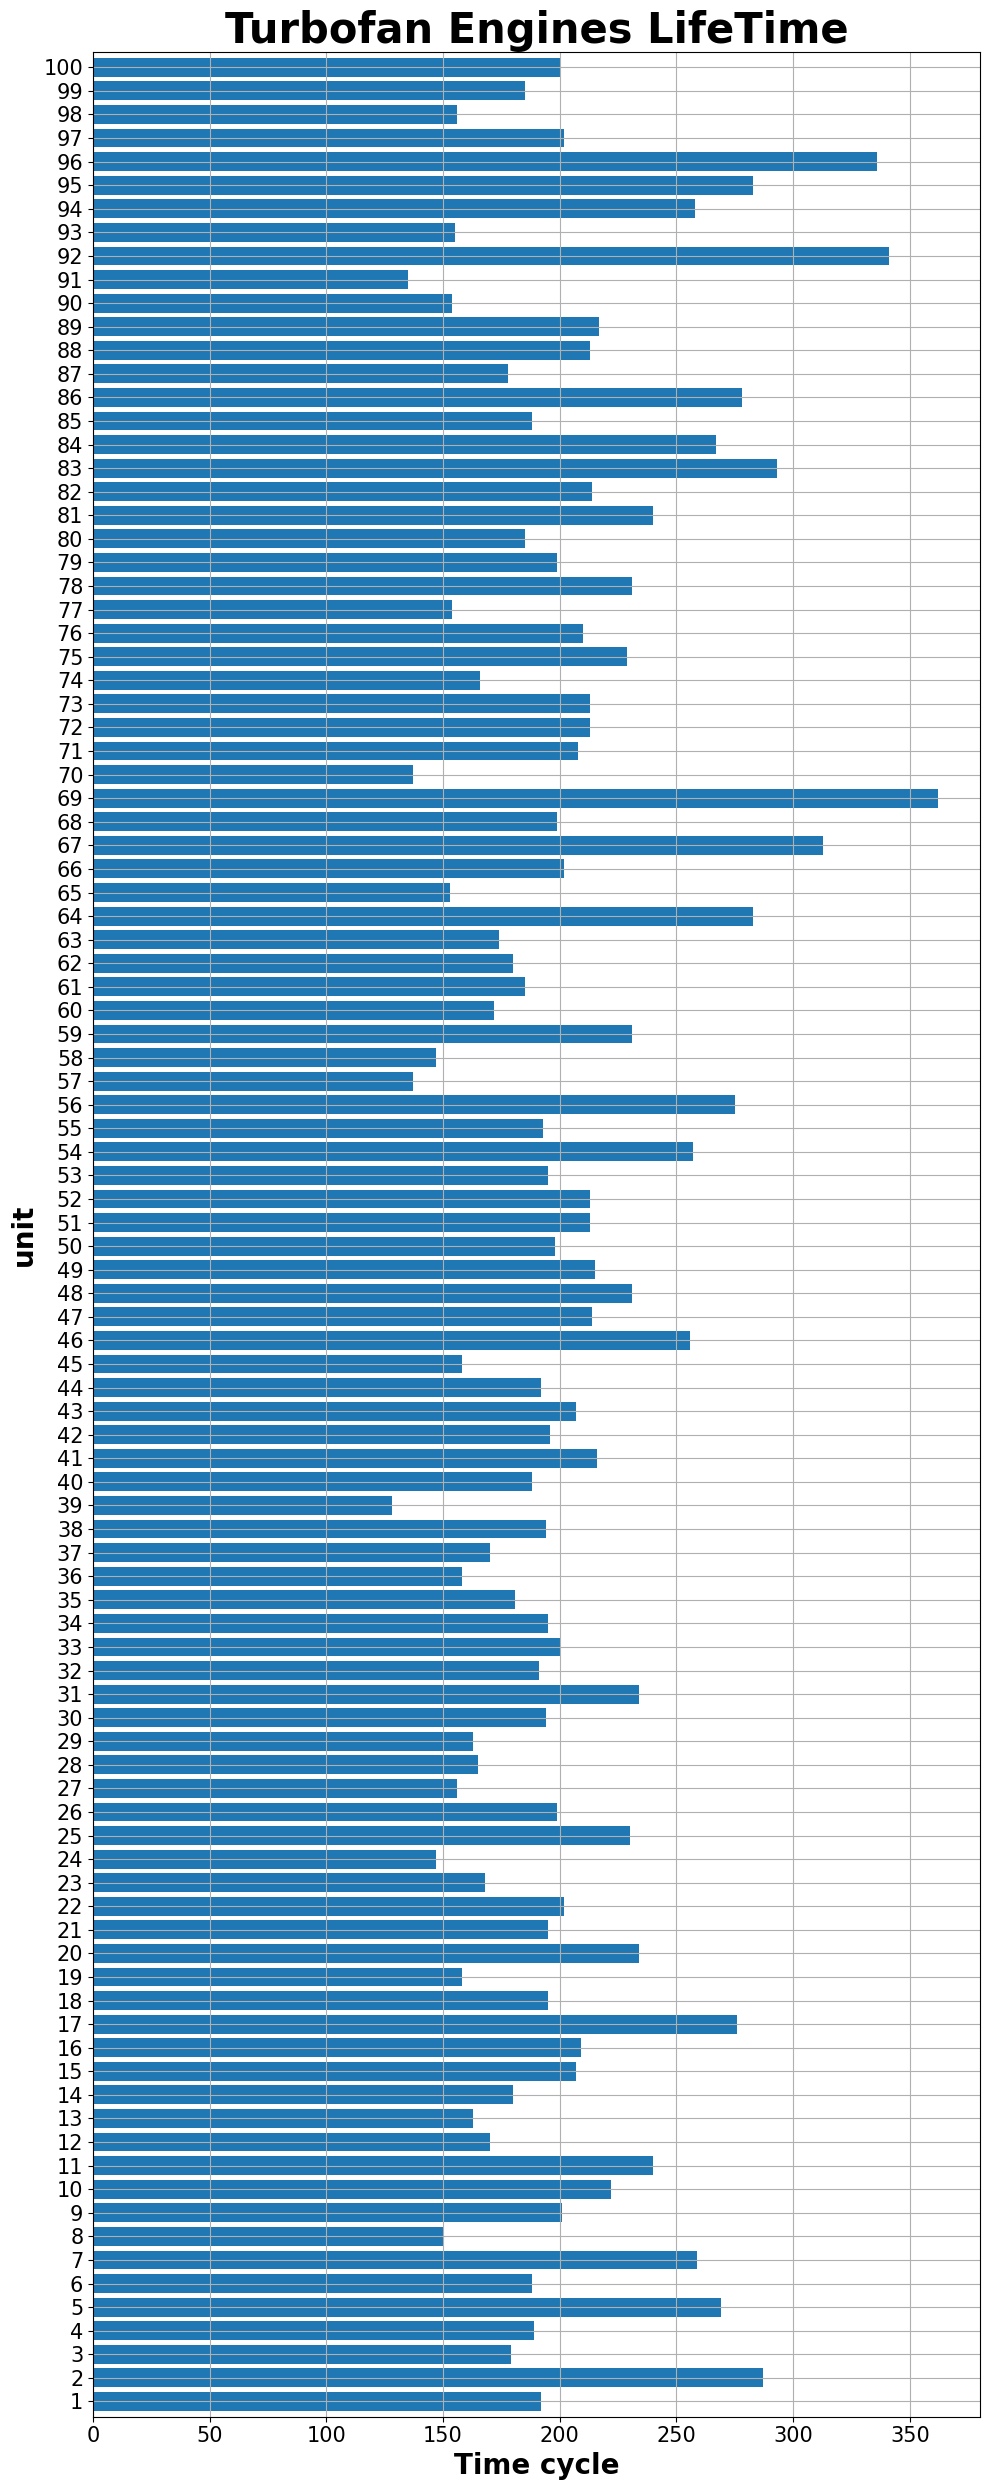

In [12]:
index_names = ['unit_number', 'time_in_cycles']
max_time_cycles=train_df[index_names].groupby('unit_number').max()
plt.figure(figsize=(10,25))
ax=max_time_cycles['time_in_cycles'].plot(kind='barh',width=0.8, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Time cycle',fontweight='bold',size=20)
plt.xticks(size=15)
plt.ylabel('unit',fontweight='bold',size=20)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.show()

## 사이클 100번 이전에는 고장이 없는 것을 확인 첫 고장은 대략 125회

### 사이클마다 최대 수명이었던 비행기의 갯수, 곡선은 커널 밀도 추정 곡선

Text(0.5, 9.444444444444459, 'max time cycle')

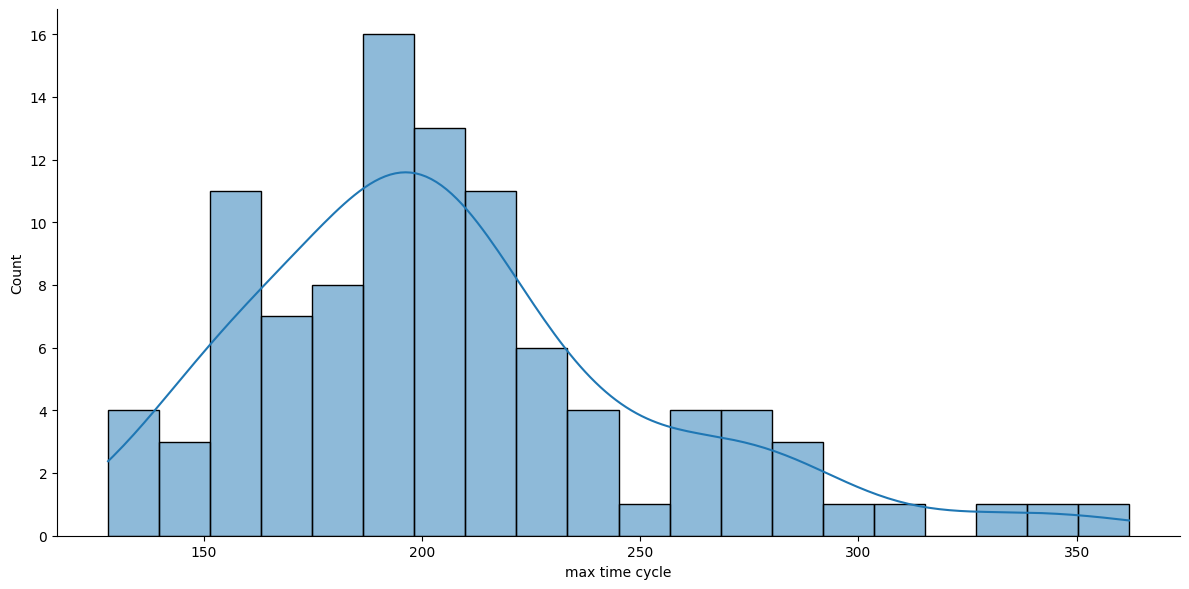

In [13]:
#Distribution of maximum time cycles
sns.displot(max_time_cycles['time_in_cycles'],kde=True,bins=20,height=6,aspect=2)
plt.xlabel('max time cycle')

   unit_number  time_in_cycles  RUL
0            1               1  100
1            1               2  100
2            1               3  100
3            1               4  100
4            1               5  100
Drawing Time Series for Unit 1 (Small Size)...


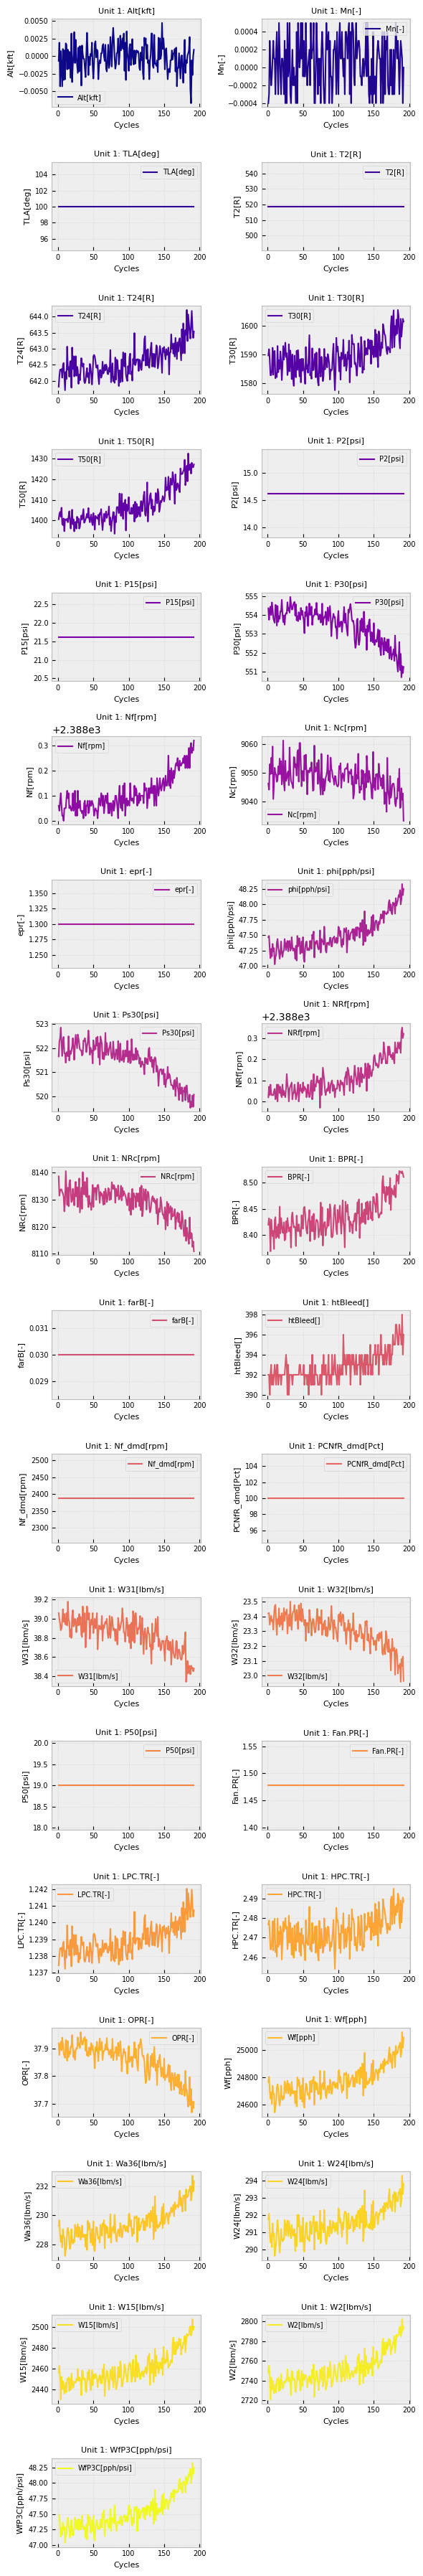

Drawing Correlation Scatter Plots (Small Size)...


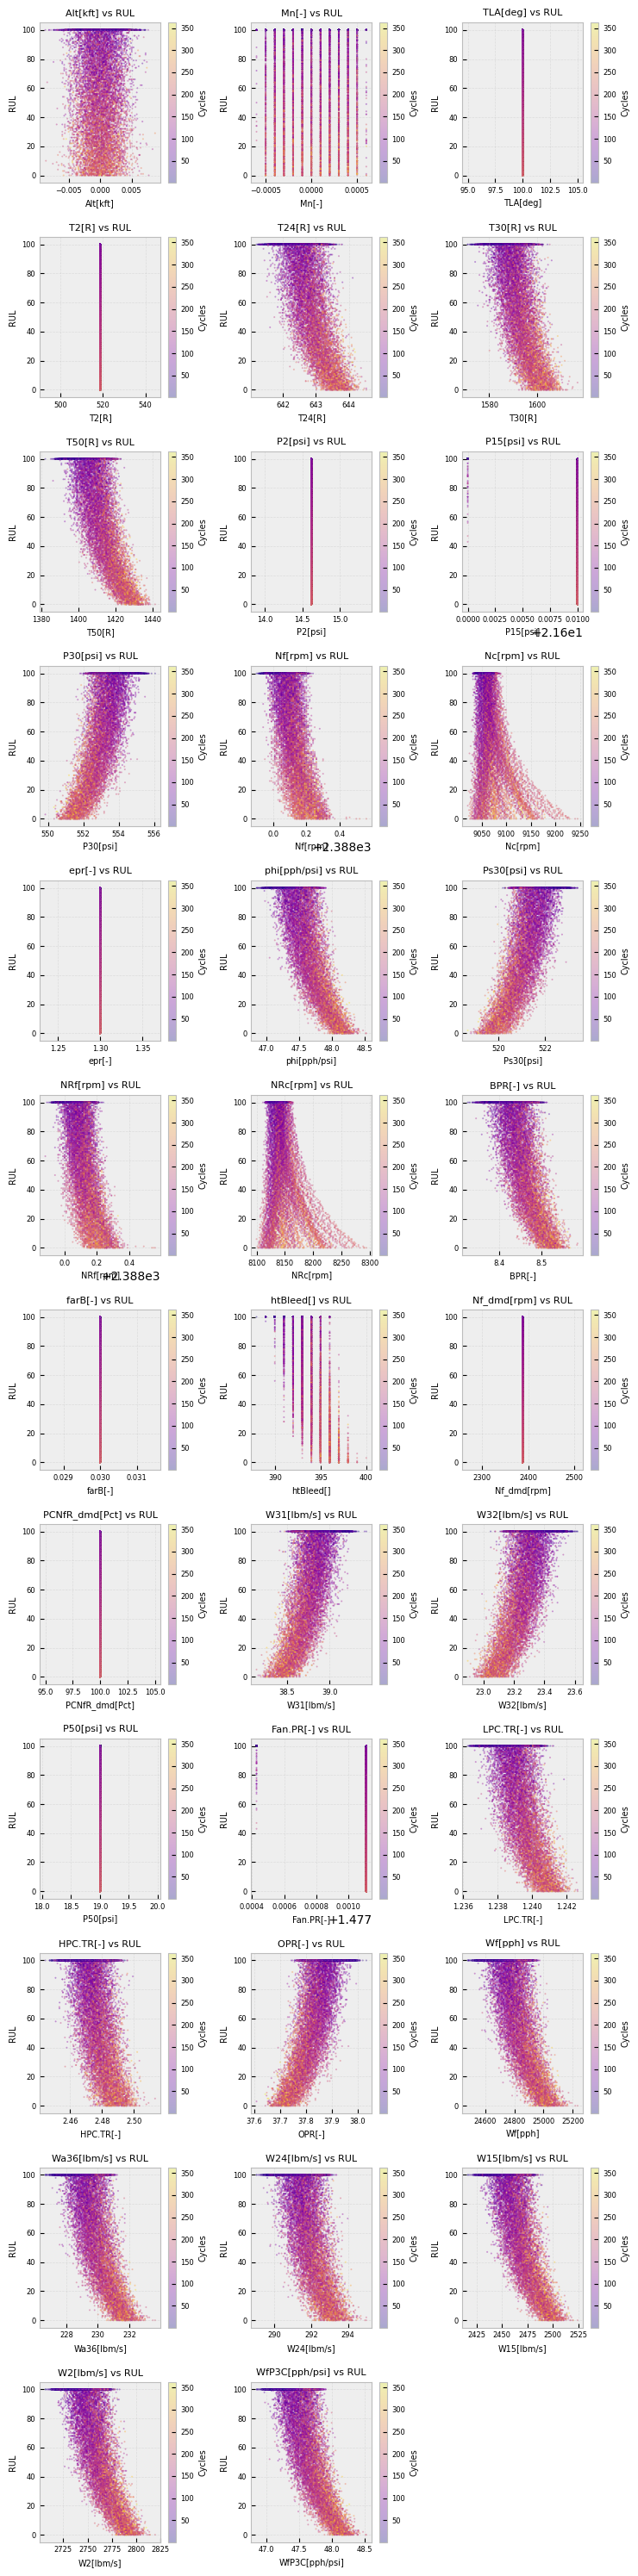

Drawing Correlation Heatmap (Original Large Size!)...


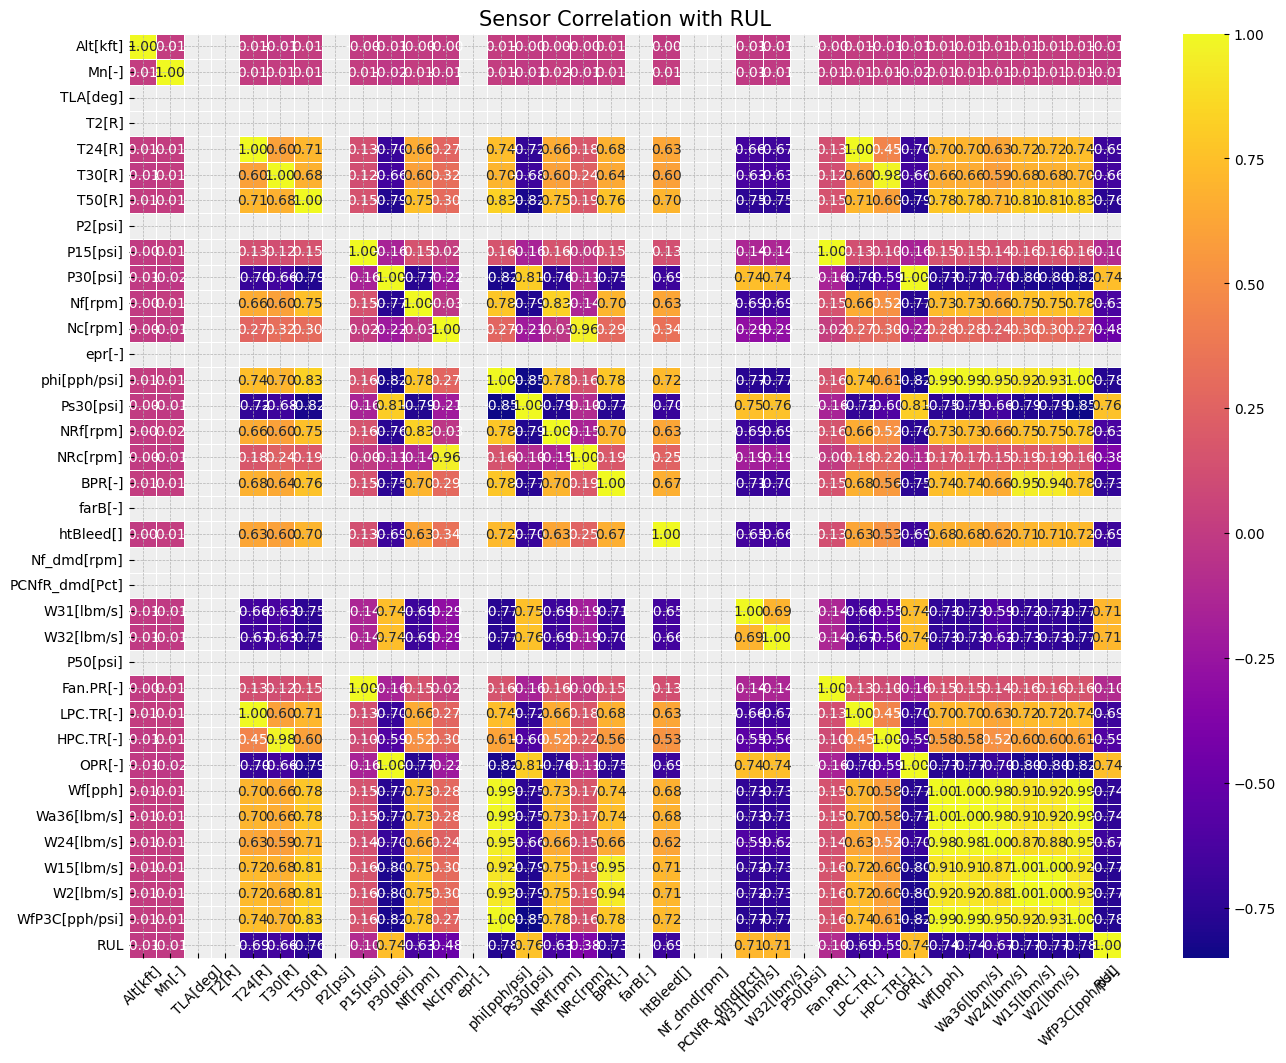

In [14]:
import math

class Plot:
    def __init__(self, dataframe):
        self.df = dataframe
        self.warnings = warnings
        
        # 스타일 설정
        plt.style.use('bmh')
        
        # 시각화할 센서 리스트: 숫자형 컬럼만 선택 (에러 방지)
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        self.sensors = [col for col in numeric_cols 
                        if col not in ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle']]
        
        self.cycles = self.df["time_in_cycles"]

    # 1. 특정 엔진의 시계열 그래프 (작은 크기 유지)
    def timeseries_single_engine(self, unit_id):
        single_engine_data = self.df[self.df["unit_number"] == unit_id]
        
        n_sensors = len(self.sensors)
        cols = 2
        rows = math.ceil(n_sensors / cols) 
        
        colors = iter(plt.cm.plasma(np.linspace(0, 1, n_sensors)))
        
        plt.figure(figsize=(6, 2 * rows)) # 작은 크기 유지
        
        for i, sensor in enumerate(self.sensors):
            c = next(colors)
            plt.subplot(rows, cols, i+1)
            
            plt.plot(single_engine_data['time_in_cycles'], 
                     single_engine_data[sensor], 
                     c=c, label=sensor, linewidth=1.5)
            
            plt.title(f"Unit {unit_id}: {sensor}", fontsize=8)
            plt.xlabel("Cycles", fontsize=8)
            plt.ylabel(sensor, fontsize=8)
            plt.tick_params(labelsize=7)
            plt.legend(loc='best', fontsize=7)
            plt.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

    # 2. 화려한 상관관계 산점도 (작은 크기 유지)
    def corr_scatter(self):
        n_sensors = len(self.sensors)
        cols = 3
        rows = math.ceil(n_sensors / cols)
        
        with self.warnings.catch_warnings(record=True):
            plt.figure(figsize=(7.5, 2.5 * rows)) # 작은 크기 유지
            
            for i, sensor in enumerate(self.sensors):
                plt.subplot(rows, cols, i+1)
                
                scatter = plt.scatter(
                    x=self.df[sensor], 
                    y=self.df["RUL"], 
                    s=1,              
                    alpha=0.3,       
                    c=self.cycles,    
                    cmap=plt.get_cmap("plasma") 
                )
                
                cbar = plt.colorbar(scatter)
                cbar.ax.tick_params(labelsize=6)
                cbar.set_label("Cycles", fontsize=7)
                
                plt.xlabel(sensor, fontsize=7)
                plt.ylabel("RUL", fontsize=7)
                plt.title(f"{sensor} vs RUL", fontsize=8)
                plt.tick_params(labelsize=6)
                plt.grid(True, alpha=0.3)
                
            plt.tight_layout()
            plt.show()
    
    # 3. 히트맵 그리기 (★원래대로 크게 복원★)
    def corr_heatmap(self, plot_title="Correlation Heatmap", corr_method='pearson'):
        cols_to_corr = self.sensors + ['RUL']
        
        # 숫자형 데이터만 강제 선택 (에러 방지)
        numeric_df = self.df[cols_to_corr].select_dtypes(include=[np.number])
        
        corr_mat = numeric_df.corr(method=corr_method)
        
        # [수정] figsize를 (16, 12)로 원래대로 크게 복원
        plt.figure(figsize=(16, 12))
        
        sns.heatmap(corr_mat.round(2), 
                    xticklabels=True, yticklabels=True, 
                    cmap="plasma", annot=True, fmt='.2f', linewidths=.5,
                    annot_kws={"size": 10}) # 폰트 크기도 다시 키움 (6 -> 10)
        
        plt.title(plot_title, fontsize=15) # 제목 폰트 키움
        plt.xticks(fontsize=10, rotation=45) # 축 글자 키움
        plt.yticks(fontsize=10)
        plt.show()


print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head())

# ---------------------------------------------------------
# 실행 (객체 생성 및 그래프 출력)
# ---------------------------------------------------------

# Plot 객체 생성
plot = Plot(train_df)

print("Drawing Time Series for Unit 1 (Small Size)...")
plot.timeseries_single_engine(1)

print("Drawing Correlation Scatter Plots (Small Size)...")
plot.corr_scatter()

print("Drawing Correlation Heatmap (Original Large Size!)...")
plot.corr_heatmap(plot_title="Sensor Correlation with RUL", corr_method='pearson')

### 첫번때 그래프 (사이클에 따른 값의 변화), 두번째 그래프 RUL과의 관계 모두 아래 컬럼은 상수 또는 막대 형태 결과 이므로 삭제.
TLA[deg], T2[R], P2[psi], P15[psi], epr[-], farB[-], Nf_dmd[rpm], PCNfR_dmd[Pct], condition, P50[Psi], Fan.PR[-]

# 데이터 전처리 

In [15]:
train_df = train_df.drop(["TLA[deg]", "T2[R]", "P2[psi]", "P15[psi]", "epr[-]", "farB[-]", "Nf_dmd[rpm]", "PCNfR_dmd[Pct]", "condition", "P50[psi]", "Fan.PR[-]"], axis=1)

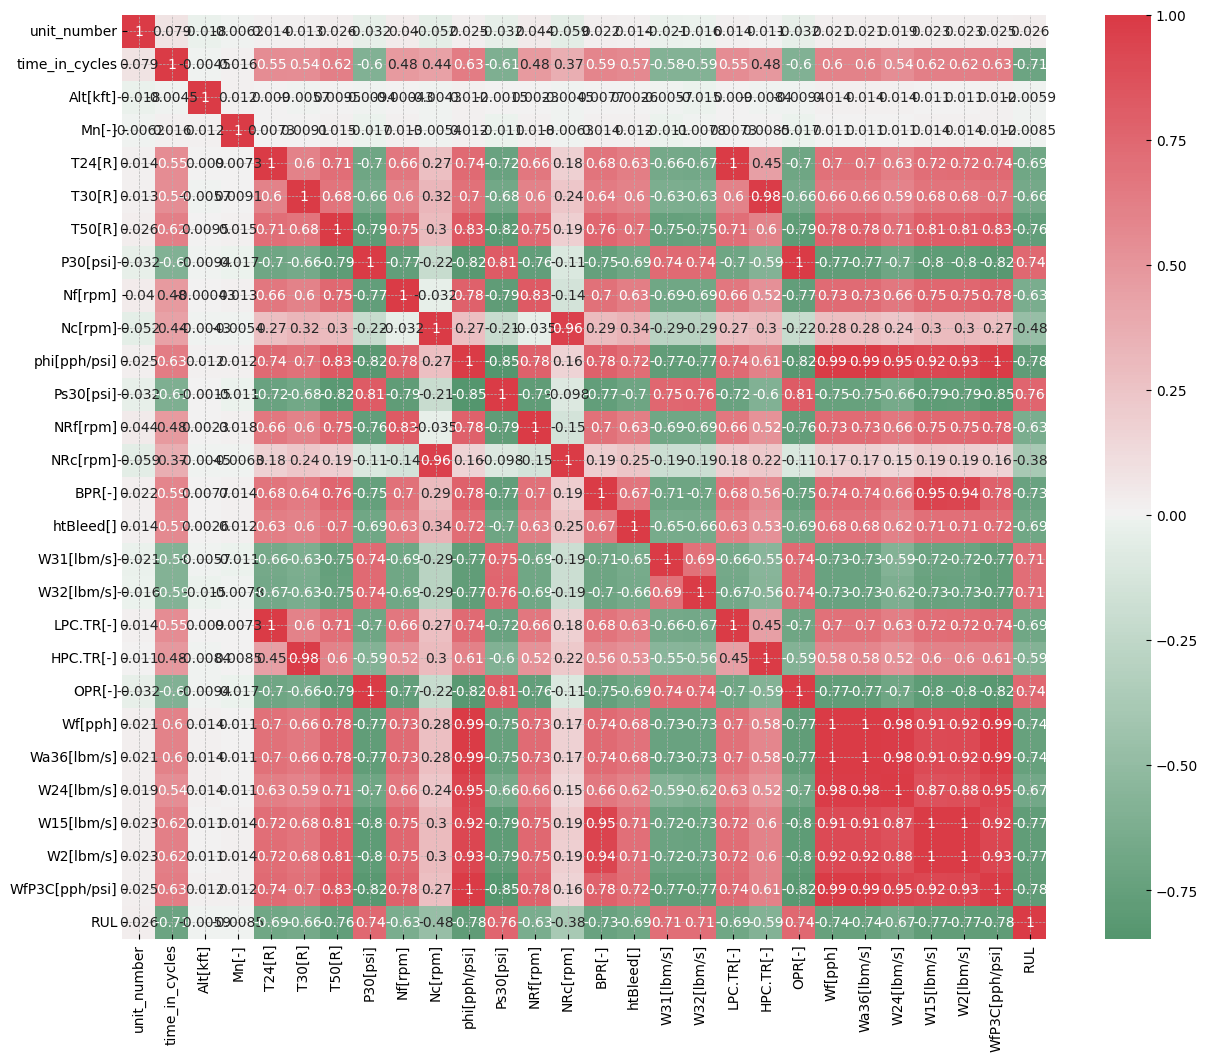

In [16]:
plt.figure(figsize=(15, 12))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(train_df.corr(), cmap =cmap, center=0, annot=True, square=True);

In [17]:
## RUL과의 상관 계수가 0.1 미만인 것을 걸러 낸다.

corr_with_rul = train_df.corrwith(train_df['RUL']).abs()
threshold = 0.1

# 1. 기준 미달 컬럼 전체 추출
low_corr_cols = corr_with_rul[corr_with_rul < threshold].index.tolist()

# 2. 보호할 컬럼 정의
protected_cols = ['unit_number', 'time_in_cycles', 'RUL']

# 3. 보호 컬럼 제외하고 진짜 삭제할 리스트 생성
final_drop_cols = [col for col in low_corr_cols if col not in protected_cols]

print(f"📉 기준 미달 전체 컬럼: {low_corr_cols}")
print(f"🛡️ 보호된 컬럼 제외 후 최종 삭제 대상: {final_drop_cols}")

# 4. 삭제 수행 (수정됨: low_corr_cols -> final_drop_cols)
if final_drop_cols:
    train_df = train_df.drop(final_drop_cols, axis=1) # 여기가 핵심 수정 사항입니다!
    print(f"\n✅ {len(final_drop_cols)}개 컬럼 안전하게 제거 완료!")
    print("남은 컬럼:", train_df.columns.tolist())
else:
    print("\n🎉 제거할 컬럼이 없습니다.")

📉 기준 미달 전체 컬럼: ['unit_number', 'Alt[kft]', 'Mn[-]']
🛡️ 보호된 컬럼 제외 후 최종 삭제 대상: ['Alt[kft]', 'Mn[-]']

✅ 2개 컬럼 안전하게 제거 완료!
남은 컬럼: ['unit_number', 'time_in_cycles', 'T24[R]', 'T30[R]', 'T50[R]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]', 'W32[lbm/s]', 'LPC.TR[-]', 'HPC.TR[-]', 'OPR[-]', 'Wf[pph]', 'Wa36[lbm/s]', 'W24[lbm/s]', 'W15[lbm/s]', 'W2[lbm/s]', 'WfP3C[pph/psi]', 'RUL']


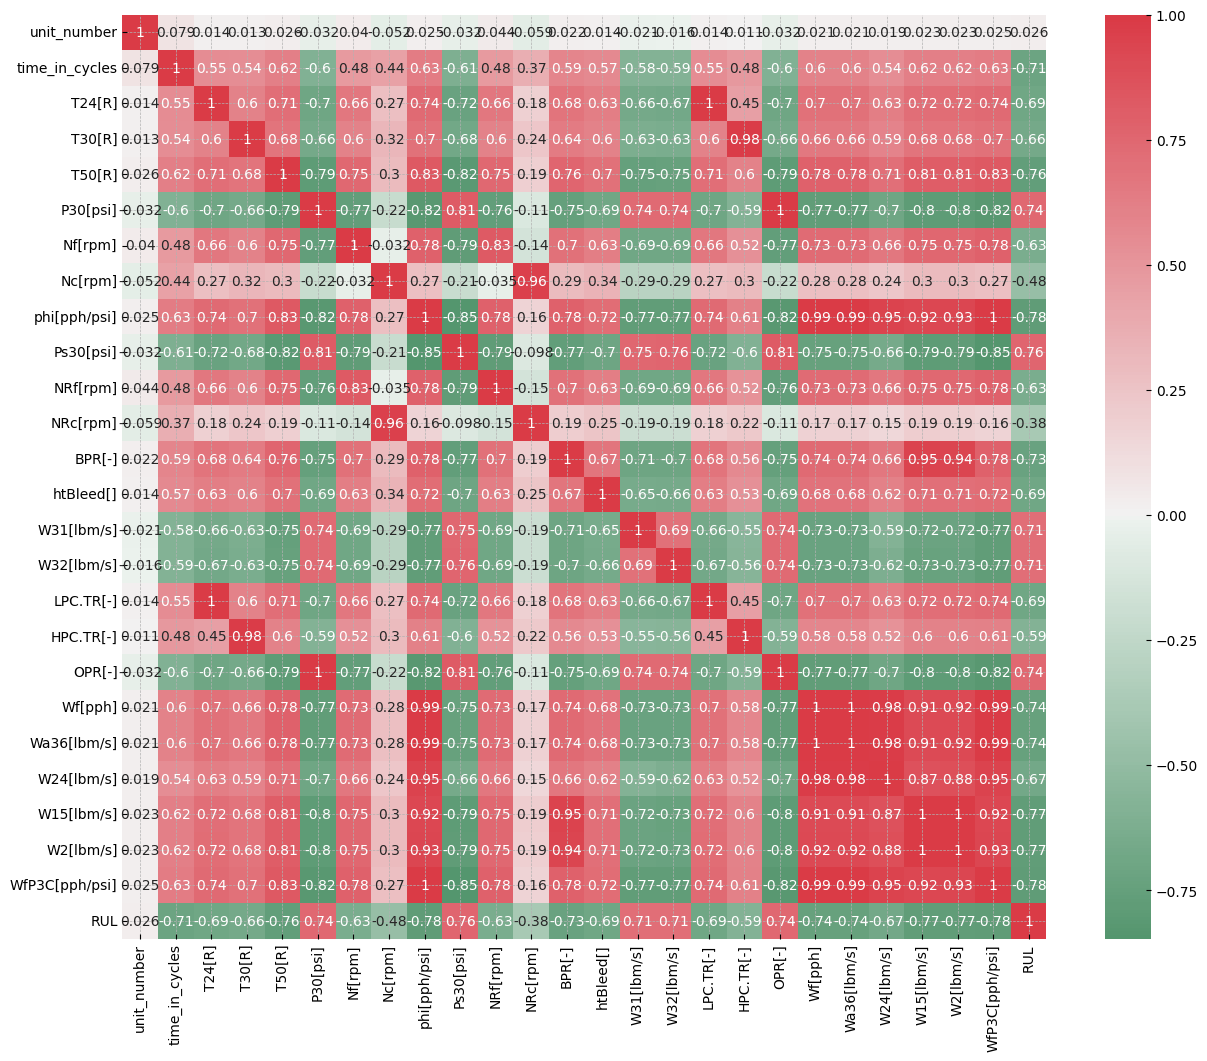

In [18]:
plt.figure(figsize=(15, 12))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(train_df.corr(), cmap =cmap, center=0, annot=True, square=True);

In [19]:
# RUL clipping 을 했기 때문에 단순히 0.9 이상이라고 제거 불가능
# 엔진이 고장 날떄는 센서값이 같이 변동하는 동반 상승 효과로 인해 상관 계수가 높을 수 있다. clipping 전에는 건강 구간도 반영되었기 때문에 그럼에도 0.9 이상이면 이상 수치였다.

# Feature Engineering 에서 만든 파생 컬럼에 대해 중복되는 컬럼을 삭제
train_df = train_df.drop(["P30[psi]","T24[R]","T30[R]",'phi[pph/psi]','BPR[-]','NRf[rpm]','NRc[rpm]'], axis=1)

# 중간 계산 변수 삭제 (최종적으로 w2를 구하기 위해 중간 발생 또는 단순 합산 변수)
train_df = train_df.drop(['Wf[pph]',"W24[lbm/s]","W31[lbm/s]","W32[lbm/s]",'Wa36[lbm/s]','W15[lbm/s]'], axis=1)

# FD0001 데이터셋 단일 고장(HPC), 단일 운전 조건 고려 불필요 컬럼 추가 삭제 
train_df = train_df.drop(['Nf[rpm]','LPC.TR[-]'], axis=1)

In [20]:
train_df.columns.tolist()

['unit_number',
 'time_in_cycles',
 'T50[R]',
 'Nc[rpm]',
 'Ps30[psi]',
 'htBleed[]',
 'HPC.TR[-]',
 'OPR[-]',
 'W2[lbm/s]',
 'WfP3C[pph/psi]',
 'RUL']

* 삭제한 컬럼의 기준 
1. 상수 값 (FD001의 단일 조건으로 인해)
2. 중복되는 내용 또는 중간 발생 변수 
3. RUL과 상관성이 낮음
4. HPC 단일 고장 이기 때문에 HPC와 관련이 적은 컬럼 삭제(LPC 관련 컬럼이나 HPC는 core에 위치해 있기 때문에 영향이 적은 Nf(fan speed)는 제거)

## *아래 3개의 컬럼은 원래 매우 중요한 컬럼*
그러나 FD001의 경우 단일 운전 조건 (Sea Level), 단일 고장 모드 (HPC Degradation만) 이기 때문에 
센서들이 서로 높은 상관관계를 갖고 패턴이 비슷해 이 데이터셋에서는 삭제해도 무방.

1. phi[pph/psi] (연료 유량 대 Ps30 비율)
이 센서는 엔진 열화와 직접적으로 관련이 있습니다. 엔진이 노화되면서 연료 효율이 떨어지고 이 값이 변화합니다.
상관관계가 높더라도 HPC 열화를 감지하는 데 중요한 지표입니다.
2. BPR[-] (바이패스 비)
엔진 성능 저하의 핵심 지표 중 하나입니다.
다른 센서와 높은 상관관계가 있어 삭제되었을 수 있지만, 물리적 의미가 다르므로 유지하는 것이 좋을 수 있습니다.
3. epr[-] (엔진 압력비 P50/P2)
엔진의 전체적인 성능을 나타내는 중요한 지표입니다.
엔진 추력과 직접 연관되어 있어 RUL 예측에 유용할 수 있습니다.

> A/B 테스트 방식으로 컬럼 삭제가 적합한지 확인하는 코드는 신경망 모델을 사용하는 방식으로 현재 머신러닝만 사용하는 룰에는 부적합
사용하더라도 무거운 신경망을 컬럼 삭제 조합마다 수십번씩 학습 시키는 매우 무거운 방식. 
직접 EDA를 통해 데이터 전처리가 가능하다면 불필요한 작업

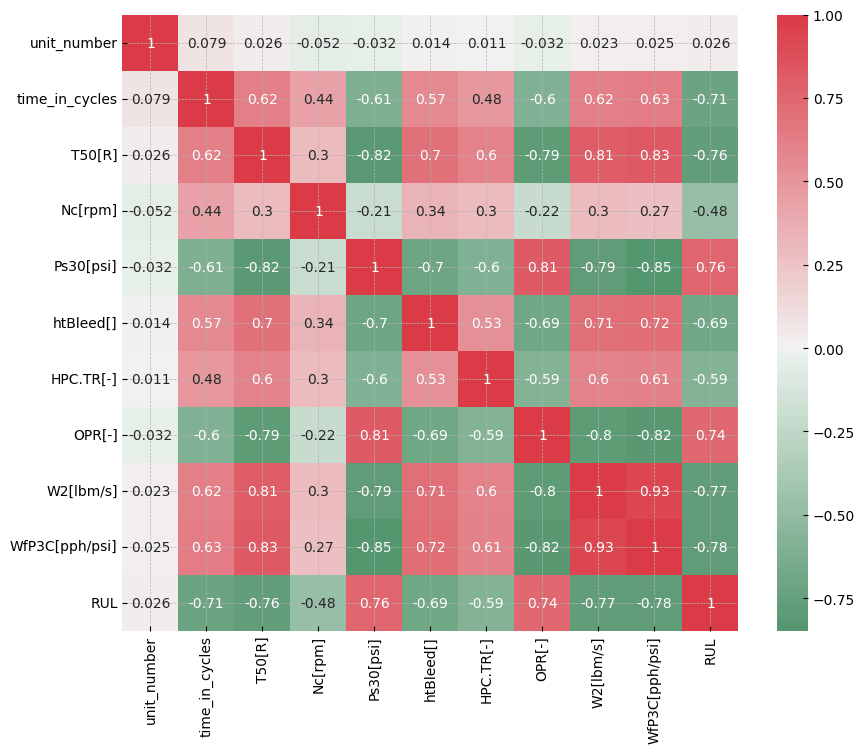

In [21]:
plt.figure(figsize=(10, 8))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(train_df.corr(), cmap =cmap, center=0, annot=True, square=True);

> w2와 WfP3C 도 상관계수가 0.93 이지만 동반 상승 효과 케이스이다. 만약 엔진 효율이 나빠져서 "연료는 많이 먹는데(WfP3C 상승), 압력은 안 차오르는(Ps30 하락)" 이러한 상황을 고려하기 위해 삭제 불가

In [22]:
train_df.columns.tolist()

['unit_number',
 'time_in_cycles',
 'T50[R]',
 'Nc[rpm]',
 'Ps30[psi]',
 'htBleed[]',
 'HPC.TR[-]',
 'OPR[-]',
 'W2[lbm/s]',
 'WfP3C[pph/psi]',
 'RUL']

### 이 문제 출제한 IEEE의 가이드인  Damage Propagation Modeling.pdf 에서 데이터에 의도적으로 초기 노이즈와 잡음 노이즈를 반영했으니 노이즈 제거 과정을 진행하라고 추천

In [23]:
# =========================================================
# 🛠️ [Train Data Prep] Advanced Feature Engineering 적용
# =========================================================

# 1. 고급 피처 생성 (Savitzky-Golay + EMA + Rolling)
print("🚀 [Train] 노이즈 제거 및 고급 피처 생성 중...")
train_df = add_advanced_features(train_df)

# 2. 결측치(NaN) 제거
# Train 데이터는 학습의 질을 위해 초기 윈도우(NaN) 구간을 과감히 삭제하는 것이 좋습니다.
# (사용자님의 기존 전략 유지)
original_len = len(train_df)
train_df.dropna(inplace=True)

print(f"\n✅ Advanced Rolling Feature 생성 완료!")
print(f"   - 삭제된 초기 데이터 행 수: {original_len - len(train_df)}개 (윈도우 초기화 구간)")
print(f"   - 총 컬럼 수: {len(train_df.columns)}개")

# 확인
new_cols = [c for c in train_df.columns if 'ema' in c or 'mean' in c]
print(f"   - 생성된 파생 변수 예시: {new_cols[:5]}...")

🚀 [Train] 노이즈 제거 및 고급 피처 생성 중...
   👉 Advanced Feature 적용 대상: 8개 컬럼

✅ Advanced Rolling Feature 생성 완료!
   - 삭제된 초기 데이터 행 수: 100개 (윈도우 초기화 구간)
   - 총 컬럼 수: 51개
   - 생성된 파생 변수 예시: ['T50[R]_ema_20', 'T50[R]_mean_5', 'T50[R]_mean_20', 'Nc[rpm]_ema_20', 'Nc[rpm]_mean_5']...


In [24]:
current_corr = train_df.corrwith(train_df['RUL']).abs().sort_values(ascending=False)

print("📊 [팩트 체크] RUL Clipping 적용 후 현재 상관계수 TOP 10:")
print(current_corr.head(15))

print("\n------------------------------------")
print(f"👉 Nc(Core Speed)의 현재 상관계수: {current_corr.get('Nc[rpm]', '이미 삭제됨')}")
print(f"👉 Nf(Fan Speed)의 현재 상관계수:  {current_corr.get('Nf[rpm]', '이미 삭제됨')}")

📊 [팩트 체크] RUL Clipping 적용 후 현재 상관계수 TOP 10:
RUL                      1.000000
W2[lbm/s]                0.837510
T50[R]                   0.833713
WfP3C[pph/psi]           0.832327
W2[lbm/s]_mean_5         0.828387
T50[R]_mean_5            0.823950
WfP3C[pph/psi]_mean_5    0.822499
htBleed[]                0.821223
htBleed[]_ema_20         0.816638
htBleed[]_mean_20        0.813868
htBleed[]_mean_5         0.812953
Ps30[psi]                0.812726
OPR[-]                   0.811452
W2[lbm/s]_ema_20         0.808777
HPC.TR[-]_ema_20         0.807766
dtype: float64

------------------------------------
👉 Nc(Core Speed)의 현재 상관계수: 0.48122447917855854
👉 Nf(Fan Speed)의 현재 상관계수:  이미 삭제됨


## GroupShuffleSplit을 적용해 train_data와 test_data를 구분
이 데이터 셋은 시계열 데이터이기 때문에 data leakage를 방지하기 위해 GroupShuffleSplit을 사용한다.

In [25]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df['Column Name']

0                unit_number
1             time_in_cycles
2                     T50[R]
3                    Nc[rpm]
4                  Ps30[psi]
5                  htBleed[]
6                  HPC.TR[-]
7                     OPR[-]
8                  W2[lbm/s]
9             WfP3C[pph/psi]
10                       RUL
11             T50[R]_ema_20
12             T50[R]_mean_5
13              T50[R]_std_5
14            T50[R]_mean_20
15             T50[R]_std_20
16            Nc[rpm]_ema_20
17            Nc[rpm]_mean_5
18             Nc[rpm]_std_5
19           Nc[rpm]_mean_20
20            Nc[rpm]_std_20
21          Ps30[psi]_ema_20
22          Ps30[psi]_mean_5
23           Ps30[psi]_std_5
24         Ps30[psi]_mean_20
25          Ps30[psi]_std_20
26          htBleed[]_ema_20
27          htBleed[]_mean_5
28           htBleed[]_std_5
29         htBleed[]_mean_20
30          htBleed[]_std_20
31          HPC.TR[-]_ema_20
32          HPC.TR[-]_mean_5
33           HPC.TR[-]_std_5
34         HPC

In [26]:
from sklearn.model_selection import GroupShuffleSplit
X = train_df.drop(['unit_number', 'RUL'], axis=1) 
y = train_df['RUL']
groups = train_df['unit_number']
# 엔진 단위로 80%는 훈련, 20%는 검증으로 나눕니다.
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)

# gss.split은 인덱스를 반환합니다.
train_idx, val_idx = next(gss.split(X, y, groups))

# 인덱스로 실제 데이터 분할
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print(f"훈련 데이터 크기: {X_train.shape}, 검증 데이터 크기: {X_val.shape}")
print(f"훈련에 사용된 엔진 수: {len(groups.iloc[train_idx].unique())}개")
print(f"검증에 사용된 엔진 수: {len(groups.iloc[val_idx].unique())}개")


훈련 데이터 크기: (16481, 49), 검증 데이터 크기: (4050, 49)
훈련에 사용된 엔진 수: 80개
검증에 사용된 엔진 수: 20개


## 테스트 데이터 생성 (train 데이터 와 동일하게 컬럼 라벨링, Feature Engineering, 마지막 사이클만 추출 해서 정답과 비교)
* 이 시점에서는 스케일링을 하지 않는다. autogluon에서 스케일링이 안된 데이터가 입력되게 하기위해서이다.   
autogluon은 전처리도 직접 진행한다.    
따라서 다른 모델을 학습시키는 셀에서 각각 개별로 pipeline을 이용해 결측치 처리 및 스케일링을 진행한다.   

* 데이터 누수를 방지하기 위해 Feature Engineering 및 전처리 과정을 train data와 분리한다.

In [27]:
# =========================================================
# 1️⃣ [Test Data Prep] X_test, y_test 생성 (Formula + Advanced Features)
# =========================================================
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter 

# 1. 원본 데이터 복사
test_working = test_df.copy()

# ---------------------------------------------------------
# [Step A] 센서 전체 매핑 (공식 계산용)
# ---------------------------------------------------------
sensor_mapping_full = {
    'sensor_1': 'T2[R]',          'sensor_2': 'T24[R]',       'sensor_3': 'T30[R]', 
    'sensor_4': 'T50[R]',         'sensor_5': 'P2[psi]',      'sensor_6': 'P15[psi]', 
    'sensor_7': 'P30[psi]',       'sensor_8': 'Nf[rpm]',      'sensor_9': 'Nc[rpm]', 
    'sensor_10': 'epr[-]',        'sensor_11': 'Ps30[psi]',   'sensor_12': 'phi[pph/psi]', 
    'sensor_13': 'NRc[rpm]',      'sensor_14': 'NRf[rpm]',    'sensor_15': 'BPR[-]', 
    'sensor_16': 'farB[-]',       'sensor_17': 'htBleed[]',   'sensor_18': 'Nf_dmd[-]', 
    'sensor_19': 'PCNfR_dmd[-]',  'sensor_20': 'W31[lbm/s]',  'sensor_21': 'W32[lbm/s]'
}
test_working.rename(columns=sensor_mapping_full, inplace=True)

# ---------------------------------------------------------
# [Step B] Feature Engineering (물리 공식 적용)
# ---------------------------------------------------------
# 1. 압력/온도 비율
test_working["P50[psi]"]  = test_working["epr[-]"] * test_working["P2[psi]"]
test_working["Fan.PR[-]"] = test_working["P15[psi]"] / test_working["P2[psi]"]
test_working["LPC.TR[-]"] = test_working["T24[R]"] / test_working["T2[R]"]
test_working["HPC.TR[-]"] = test_working["T30[R]"] / test_working["T24[R]"]
test_working["OPR[-]"]    = test_working["P30[psi]"] / test_working["P2[psi]"]

# 2. 유량(Flow) 계산
test_working["Wf[pph]"]     = test_working["phi[pph/psi]"] * test_working["Ps30[psi]"]
test_working["Wa36[lbm/s]"] = test_working["Wf[pph]"] / 3600.0 / test_working["farB[-]"]
test_working["W24[lbm/s]"]  = test_working["Wa36[lbm/s]"] + test_working["W31[lbm/s]"] + test_working["W32[lbm/s]"]
test_working["W15[lbm/s]"]  = test_working["W24[lbm/s]"] * test_working["BPR[-]"]
test_working["W2[lbm/s]"]   = test_working["W15[lbm/s]"] + test_working["W24[lbm/s]"]

# 3. 보정 연료 유량 (WfP3C)
t2_safe = test_working["T2[R]"].replace(0, 518.67) 
test_working["WfP3C[pph/psi]"] = test_working["phi[pph/psi]"] / np.sqrt(t2_safe / 518.67)

# ---------------------------------------------------------
# [Step C] 노이즈 제거 및 롤링 윈도우
# ---------------------------------------------------------
target_cols_to_process = [
    'T50[R]', 'Nc[rpm]', 'Ps30[psi]', 'htBleed[]', 
    'HPC.TR[-]', 'OPR[-]', 'W2[lbm/s]', 'WfP3C[pph/psi]'
]

for col in target_cols_to_process:
    if col not in test_working.columns: continue
        
    grouped = test_working.groupby('unit_number')[col]
    
    try:
        test_working[col] = grouped.transform(
            lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
        )
    except: pass 

    test_working[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
    
    test_working[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
    test_working[f"{col}_std_5"]  = grouped.rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
    test_working[f"{col}_mean_20"] = grouped.rolling(window=20, min_periods=1).mean().reset_index(0, drop=True)
    test_working[f"{col}_std_20"] = grouped.rolling(window=20, min_periods=1).std().reset_index(0, drop=True)

test_working.fillna(0, inplace=True)

# ---------------------------------------------------------
# [Step D] X_test, y_test 확정 (마지막 시점만 추출)
# ---------------------------------------------------------
test_last = test_working.groupby('unit_number').last().reset_index()

if 'unit_number' not in rul_df.columns:
    rul_df['unit_number'] = range(1, len(rul_df) + 1)
test_final = pd.merge(test_last, rul_df, on='unit_number')

X_test = test_final.reindex(columns=X_train.columns)
y_test = test_final['RUL']

X_test.fillna(X_train.median(), inplace=True)

print(f"✅ [Test Data Prep] 완료!")
print(f"👉 X_test shape: {X_test.shape}")
print(f"👉 WfP3C 컬럼 존재 확인: {'WfP3C[pph/psi]' in X_test.columns}")

✅ [Test Data Prep] 완료!
👉 X_test shape: (100, 49)
👉 WfP3C 컬럼 존재 확인: True


* Predicted RUL과 Real RUL 비교 그래프를 그리기 위해 마지막 사이클의 RUL 만이 아닌 전체 시계열 정담인 RUL 컬럼을 'test_working'에 채워 넣는다.

RMSE의 함정: 모델 A는 전 구간에서 오차가 10이고, 모델 B는 평소엔 오차가 0이다가 고장 직전에 오차가 100이라면? 둘의 RMSE는 비슷할 수 있지만, 현장에서는 모델 B를 쓰면 사고가 납니다.

In [28]:
# =========================================================
# 🎨 [Visualization Prep] 시각화용 데이터(test_working) 생성
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter 

# 1. 원본 데이터 복사 (위와 독립적으로 새로 생성)
test_working = test_df.copy()

# ---------------------------------------------------------
# [Step A] 센서 전체 매핑
# ---------------------------------------------------------
sensor_mapping_full = {
    'sensor_1': 'T2[R]',          'sensor_2': 'T24[R]',       'sensor_3': 'T30[R]', 
    'sensor_4': 'T50[R]',         'sensor_5': 'P2[psi]',      'sensor_6': 'P15[psi]', 
    'sensor_7': 'P30[psi]',       'sensor_8': 'Nf[rpm]',      'sensor_9': 'Nc[rpm]', 
    'sensor_10': 'epr[-]',        'sensor_11': 'Ps30[psi]',   'sensor_12': 'phi[pph/psi]', 
    'sensor_13': 'NRc[rpm]',      'sensor_14': 'NRf[rpm]',    'sensor_15': 'BPR[-]', 
    'sensor_16': 'farB[-]',       'sensor_17': 'htBleed[]',   'sensor_18': 'Nf_dmd[-]', 
    'sensor_19': 'PCNfR_dmd[-]',  'sensor_20': 'W31[lbm/s]',  'sensor_21': 'W32[lbm/s]'
}
test_working.rename(columns=sensor_mapping_full, inplace=True)

# ---------------------------------------------------------
# [Step B] Feature Engineering (동일한 공식 적용)
# ---------------------------------------------------------
test_working["P50[psi]"]  = test_working["epr[-]"] * test_working["P2[psi]"]
test_working["Fan.PR[-]"] = test_working["P15[psi]"] / test_working["P2[psi]"]
test_working["LPC.TR[-]"] = test_working["T24[R]"] / test_working["T2[R]"]
test_working["HPC.TR[-]"] = test_working["T30[R]"] / test_working["T24[R]"]
test_working["OPR[-]"]    = test_working["P30[psi]"] / test_working["P2[psi]"]

test_working["Wf[pph]"]     = test_working["phi[pph/psi]"] * test_working["Ps30[psi]"]
test_working["Wa36[lbm/s]"] = test_working["Wf[pph]"] / 3600.0 / test_working["farB[-]"]
test_working["W24[lbm/s]"]  = test_working["Wa36[lbm/s]"] + test_working["W31[lbm/s]"] + test_working["W32[lbm/s]"]
test_working["W15[lbm/s]"]  = test_working["W24[lbm/s]"] * test_working["BPR[-]"]
test_working["W2[lbm/s]"]   = test_working["W15[lbm/s]"] + test_working["W24[lbm/s]"]

t2_safe = test_working["T2[R]"].replace(0, 518.67) 
test_working["WfP3C[pph/psi]"] = test_working["phi[pph/psi]"] / np.sqrt(t2_safe / 518.67)

# ---------------------------------------------------------
# [Step C] 노이즈 제거 및 롤링 윈도우
# ---------------------------------------------------------
target_cols_to_process = [
    'T50[R]', 'Nc[rpm]', 'Ps30[psi]', 'htBleed[]', 
    'HPC.TR[-]', 'OPR[-]', 'W2[lbm/s]', 'WfP3C[pph/psi]'
]

for col in target_cols_to_process:
    if col not in test_working.columns: continue
        
    grouped = test_working.groupby('unit_number')[col]
    
    try:
        test_working[col] = grouped.transform(
            lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
        )
    except: pass 

    test_working[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
    
    test_working[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
    test_working[f"{col}_std_5"]  = grouped.rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
    test_working[f"{col}_mean_20"] = grouped.rolling(window=20, min_periods=1).mean().reset_index(0, drop=True)
    test_working[f"{col}_std_20"] = grouped.rolling(window=20, min_periods=1).std().reset_index(0, drop=True)

test_working.fillna(0, inplace=True)

# ---------------------------------------------------------
# [Step D] RUL 역산 (그래프용) & 시각화 함수 정의
# ---------------------------------------------------------
max_cycles = test_working.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

if 'unit_number' not in rul_df.columns:
    rul_df['unit_number'] = range(1, len(rul_df) + 1)
    
test_working = test_working.merge(max_cycles, on='unit_number', how='left')
rul_df_renamed = rul_df[['unit_number', 'RUL']].rename(columns={'RUL': 'RUL_final'})
test_working = test_working.merge(rul_df_renamed, on='unit_number', how='left')

test_working['RUL'] = test_working['RUL_final'] + (test_working['max_cycle'] - test_working['time_in_cycles'])
test_working.drop(columns=['max_cycle', 'RUL_final'], inplace=True)


def plot_engine_trajectory_v2(model_name, pipeline, test_full_df, unit_id, feature_cols):
    engine_data = test_full_df[test_full_df['unit_number'] == unit_id].copy()
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    X_engine = engine_data[feature_cols]
    y_true = engine_data['RUL']
    
    y_pred = pipeline.predict(X_engine)
    
    # [Safety Margin -3 적용]
    y_pred = y_pred - 3
    y_pred = np.maximum(y_pred, 0)

    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-', label=f'Pred by {model_name} (Margin -3)', alpha=0.8)
    plt.title(f"Engine Unit #{unit_id} - RUL Trajectory ({model_name})")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("✅ [Visualization Prep] 완료!")
print(f"👉 test_working shape: {test_working.shape}")
print(f"👉 WfP3C 확인: {'WfP3C[pph/psi]' in test_working.columns}")

✅ [Visualization Prep] 완료!
👉 test_working shape: (13096, 78)
👉 WfP3C 확인: True


* 전통적인 모델 중 이 데이터셋에 적합한 6가지 모델 사용 후 비교

* Optuna를 이용해 하이퍼패러미터를 적용

In [30]:
import optuna
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 모델 라이브러리
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# =========================================================
# 0.Custom Objective 정의
# =========================================================

def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    # d < 0 (Early Prediction): 페널티 작음 (exp(-d/13))
    # d > 0 (Late Prediction): 페널티 큼 (exp(d/10)) -> 고장났는데 안났다고 하면 큰일남!
    scores = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(scores)

def nasa_custom_obj(y_true, y_pred):
    """
    XGBoost / LightGBM용 Custom Objective Function
    Gradient(1차 미분)와 Hessian(2차 미분)을 반환해야 함
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    d = y_pred - y_true # Error
    
    # Gradient (d < 0: early, d >= 0: late)
    grad = np.where(d < 0, 
                    -1/13 * np.exp(-d/13), 
                    1/10 * np.exp(d/10))
    
    # Hessian
    hess = np.where(d < 0, 
                    1/169 * np.exp(-d/13), 
                    1/100 * np.exp(d/10))
    
    return grad, hess

# =========================================================
# 1. 모델 튜닝 설정 (Custom Objective 적용)
# =========================================================
models = {} 

def get_model_from_trial(trial, model_name):
    
    if model_name == 'Ridge':
        params = {
            'alpha': trial.suggest_float('alpha', 0.1, 200.0, log=True), 
            'random_state': 42
        }
        return Ridge(**params)

    elif model_name == 'SVR':
        params = {
            'C': trial.suggest_float('C', 0.1, 1000.0, log=True),        
            'epsilon': trial.suggest_float('epsilon', 0.001, 1.0, log=True), 
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        }
        return SVR(kernel='rbf', **params)
    
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_jobs': -1, 
            'random_state': 42,
            'objective': nasa_custom_obj  # [핵심] Custom Objective 적용!
        }
        return XGBRegressor(**params)

    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'verbose': -1, 
            'random_state': 42,
            'objective': nasa_custom_obj  # [핵심] Custom Objective 적용!
        }
        return LGBMRegressor(**params)

    elif model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'n_jobs': -1, 'random_state': 42
        }
        return RandomForestRegressor(**params)
        

    elif model_name == 'KNN':
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 20),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'p': trial.suggest_int('p', 1, 2)
        }
        return KNeighborsRegressor(**params)
    
    return None

def objective(trial, model_name):
    model = get_model_from_trial(trial, model_name)
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # 3-Fold CV
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    # SVR 등 느린 모델을 위한 샘플링 (기존 로직 유지)
    if model_name == 'SVR' and len(X_train) > 5000:
        sample_idx = np.random.choice(len(X_train), size=5000, replace=False)
        X_tr_tuning = X_train.iloc[sample_idx]
        y_tr_tuning = y_train.iloc[sample_idx]
    else:
        X_tr_tuning = X_train
        y_tr_tuning = y_train

    for train_idx, val_idx in kf.split(X_tr_tuning):
        X_tr = X_tr_tuning.iloc[train_idx]
        X_val = X_tr_tuning.iloc[val_idx]
        y_tr = y_tr_tuning.iloc[train_idx]
        y_val = y_tr_tuning.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        pred = pipeline.predict(X_val)
        
        # [변경] RMSE 대신 NASA Scoring Function 사용
        score = compute_nasa_score(y_val, pred)
        scores.append(score)
        
    return np.mean(scores) # Fold별 NASA 점수의 평균을 최소화

# =========================================================
# 3. 튜닝 실행 루프
# =========================================================
target_models = ['XGBoost', 'LightGBM', 'RandomForest', 'KNN', 'SVR', 'Ridge']

print("🚀 [Hyperparameter Tuning] NASA Scoring 기반 최적화 시작...")

for name in target_models:
    print(f"\n🔧 Tuning {name}...", end=" ")
    
    n_trials = 10 if name == 'SVR' else 20
    
    study = optuna.create_study(direction='minimize') # 점수는 낮을수록 좋음
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study.optimize(lambda trial: objective(trial, name), n_trials=n_trials)
    
    print(f"-> Best NASA Score: {study.best_value:,.2f}")
    
    best_model = get_model_from_trial(study.best_trial, name)
    models[name] = best_model

print("\n✨ 모든 모델 튜닝 완료! 이제 모델들은 NASA 점수에 최적화되었습니다.")

🚀 [Hyperparameter Tuning] NASA Scoring 기반 최적화 시작...

🔧 Tuning XGBoost... -> Best NASA Score: 2,794.41

🔧 Tuning LightGBM... 

Exception in thread Thread-9 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\user\miniconda3\envs\DS\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\user\miniconda3\envs\DS\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\user\miniconda3\envs\DS\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


-> Best NASA Score: 2,841.11

🔧 Tuning RandomForest... -> Best NASA Score: 4,012.14

🔧 Tuning KNN... -> Best NASA Score: 2,794.47

🔧 Tuning SVR... -> Best NASA Score: 2,878.36

🔧 Tuning Ridge... -> Best NASA Score: 13,068.96

✨ 모든 모델 튜닝 완료! 이제 모델들은 NASA 점수에 최적화되었습니다.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

# =========================================================
# 🚀 [Phase 1] 최종 모델 성능 종합 평가 (Safety Margin -3 적용)
# =========================================================
print("\n🚀 [Phase 1] 최종 모델 성능 비교 시작 (NASA Score + 5대 지표)...")
print("*" * 110)
print(f"{'Model':<12} | {'NASA Score':<12} | {'RMSE':<10} | {'RMSLE':<10} | {'MAE':<10} | {'R2':<10}")
print("-" * 110)

# 1. NASA Asymmetric Score 함수 정의 (안전을 위해 여기서 재정의)
# (Late Prediction에 가중치를 두어 벌점을 매기는 공식)
def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    # d < 0 (Early Prediction): 페널티 작음 (exp(-d/13))
    # d > 0 (Late Prediction): 페널티 큼 (exp(d/10)) -> 고장났는데 안났다고 하면 큰일남!
    scores = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(scores)

results_list = []

# models 딕셔너리에 있는 모든 모델(Ridge, SVR, XGB 등)을 순회하며 평가
for name, model in models.items():
    # (1) 파이프라인 생성: 결측치처리 -> 스케일링 -> 모델
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # (2) 전체 데이터로 재학습 (Optuna로 찾은 최적 파라미터 적용됨)
    pipeline.fit(X_train, y_train)
    
    # (3) 테스트 데이터(X_test) 예측
    # X_test는 각 엔진의 '마지막 시점' 데이터여야 합니다.
    y_pred = pipeline.predict(X_test)
    
    # 🔥 [핵심 전략] Safety Margin 적용 (Technique C)
    # 예측값에서 3을 빼서 "약간 일찍 고장난다고" 예측하게 만듦 -> Late Prediction 방지
    y_pred = y_pred - 3
    
    # (4) 음수 보정 (물리적으로 불가능한 값 제거 및 RMSLE 에러 방지)
    y_pred = np.maximum(y_pred, 0)

    # (5) 모든 평가지표 계산
    nasa_score = compute_nasa_score(y_test, y_pred)  # 낮을수록 좋음
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # 낮을수록 좋음
    mae = mean_absolute_error(y_test, y_pred)          # 낮을수록 좋음
    r2 = r2_score(y_test, y_pred)                      # 1에 가까울수록 좋음 (높을수록 좋음)
    
    # RMSLE (로그 오차, 에러 방지 처리 포함)
    try:
        rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    except:
        rmsle = 0.0 # 만약 계산 불가능하면 0 처리

    # 결과 리스트에 저장
    results_list.append({
        'Model': name,
        'NASA Score': nasa_score,
        'RMSE': rmse,
        'RMSLE': rmsle,
        'MAE': mae,
        'R2': r2
    })
    
    # 한 줄씩 출력 (진행 상황 확인용)
    print(f"{name:<12} | {nasa_score:<12.2f} | {rmse:<10.4f} | {rmsle:<10.4f} | {mae:<10.4f} | {r2:<10.4f}")

print("*" * 110)

# 2. 결과 요약 및 우승 모델 선정
results_df = pd.DataFrame(results_list).set_index('Model')

# NASA Score가 가장 낮은(좋은) 모델 선정
best_model_name = results_df['NASA Score'].idxmin()
best_score = results_df.loc[best_model_name, 'NASA Score']

print(f"\n🏆 Best Model (by NASA Score): {best_model_name}")
print(f"💎 Score: {best_score:.2f} (낮을수록 좋으며, 500점 이하면 매우 우수함)")

print("\n📊 [Score 기준 정렬된 전체 결과표]")
print(results_df.sort_values('NASA Score'))

# (선택 사항) CSV로 결과 저장
# results_df.to_csv("Phase1_Model_Evaluation.csv")


🚀 [Phase 1] 최종 모델 성능 비교 시작 (NASA Score + 5대 지표)...
**************************************************************************************************************
Model        | NASA Score   | RMSE       | RMSLE      | MAE        | R2        
--------------------------------------------------------------------------------------------------------------
XGBoost      | 786.20       | 22.5705    | 0.4256     | 16.7120    | 0.7050    
LightGBM     | 836.17       | 22.4421    | 0.4087     | 16.3254    | 0.7083    
RandomForest | 894.79       | 22.9302    | 0.3711     | 17.1006    | 0.6955    
KNN          | 1362.69      | 24.1971    | 0.4147     | 18.3356    | 0.6609    
SVR          | 567.58       | 20.0728    | 0.2803     | 14.9470    | 0.7667    
Ridge        | 840.91       | 23.1445    | 0.5136     | 17.8767    | 0.6898    
**************************************************************************************************************

🏆 Best Model (by NASA Score): SVR
💎 Score: 567.58 (낮을수

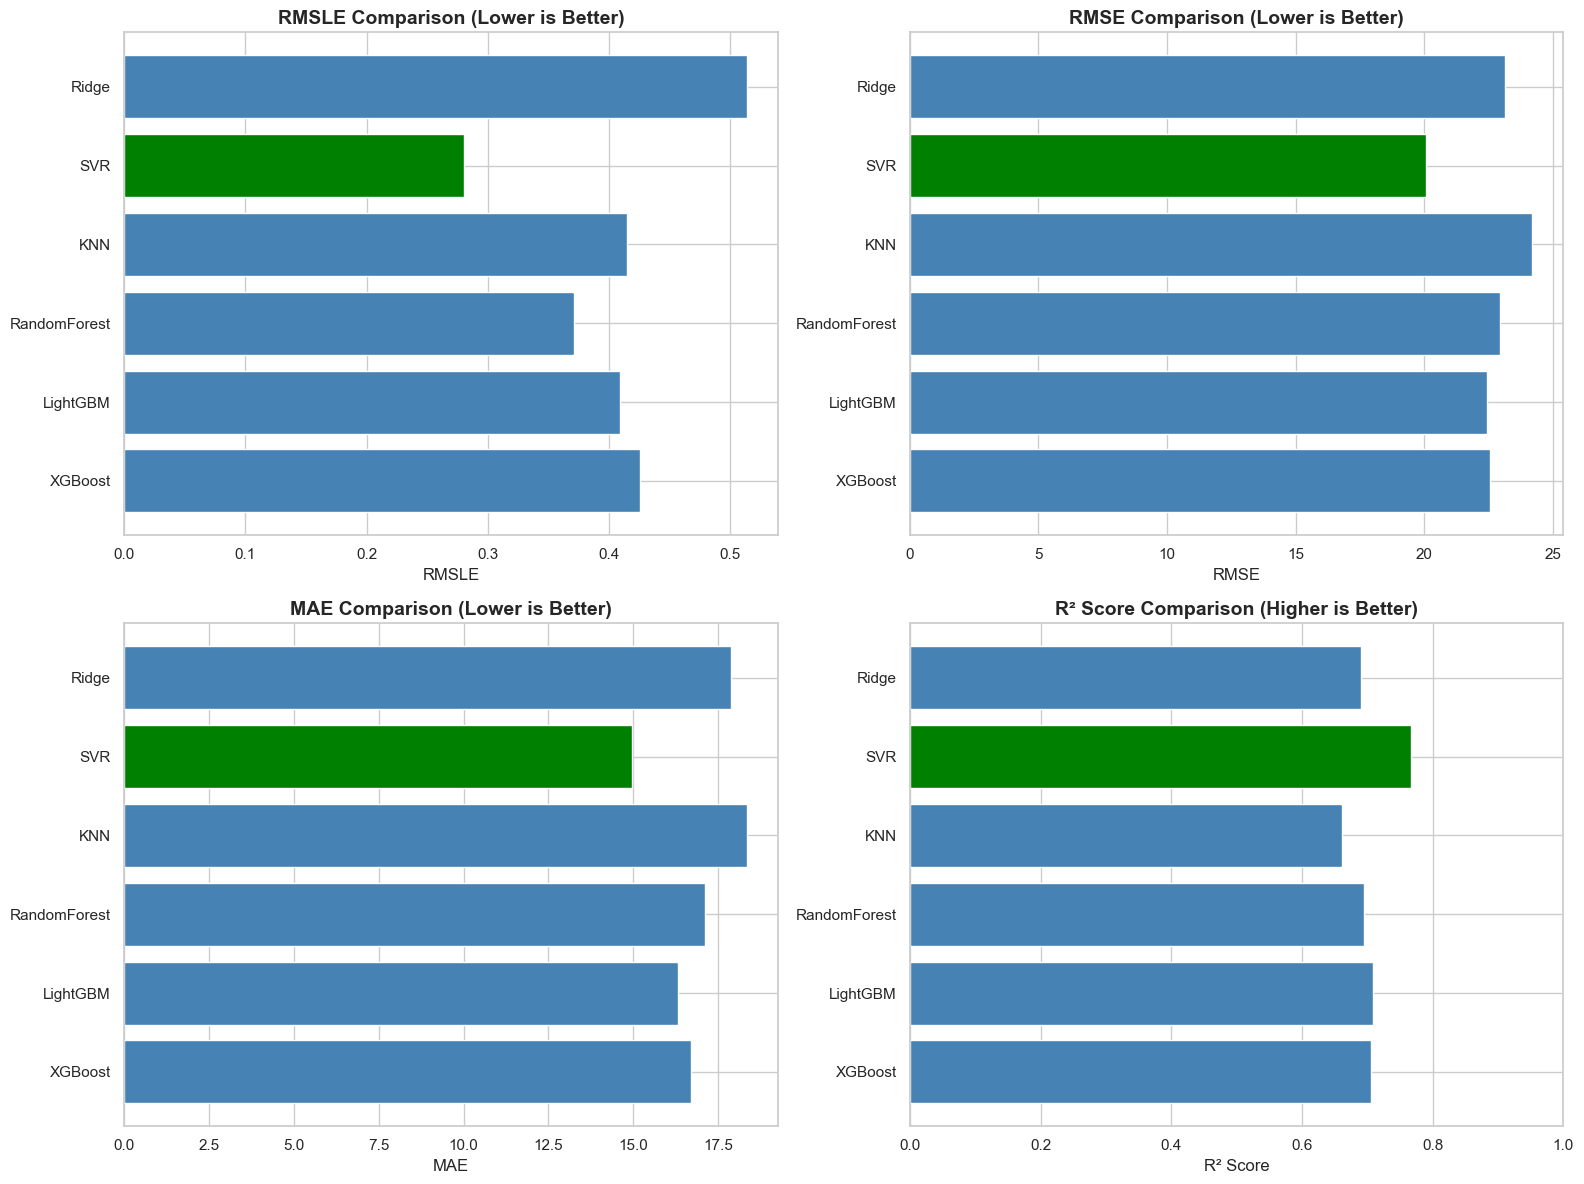

In [32]:
# =========================================================
# 📈 [Visualization] 모델 성능 비교 시각화
# =========================================================

# 그래프 스타일 설정
sns.set(style="whitegrid")

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSLE 비교 (낮을수록 좋음)
# 가장 낮은(좋은) 값은 초록색, 나머지는 파란색
colors_rmsle = ['green' if x == results_df['RMSLE'].min() else 'steelblue' for x in results_df['RMSLE']]
axes[0, 0].barh(results_df.index, results_df['RMSLE'], color=colors_rmsle)
axes[0, 0].set_title('RMSLE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('RMSLE')

# 2. RMSE 비교 (낮을수록 좋음)
colors_rmse = ['green' if x == results_df['RMSE'].min() else 'steelblue' for x in results_df['RMSE']]
axes[0, 1].barh(results_df.index, results_df['RMSE'], color=colors_rmse)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('RMSE')

# 3. MAE 비교 (낮을수록 좋음)
colors_mae = ['green' if x == results_df['MAE'].min() else 'steelblue' for x in results_df['MAE']]
axes[1, 0].barh(results_df.index, results_df['MAE'], color=colors_mae)
axes[1, 0].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('MAE')

# 4. R² Score 비교 (높을수록 좋음)
# 가장 높은(좋은) 값은 초록색
colors_r2 = ['green' if x == results_df['R2'].max() else 'steelblue' for x in results_df['R2']]
axes[1, 1].barh(results_df.index, results_df['R2'], color=colors_r2)
axes[1, 1].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('R² Score')
axes[1, 1].set_xlim(0, 1) # R2는 보통 0~1 사이

plt.tight_layout()
plt.show()

🎨 [Visualization] Unit 24 예측 패턴 확인 (Margin -3 적용됨)


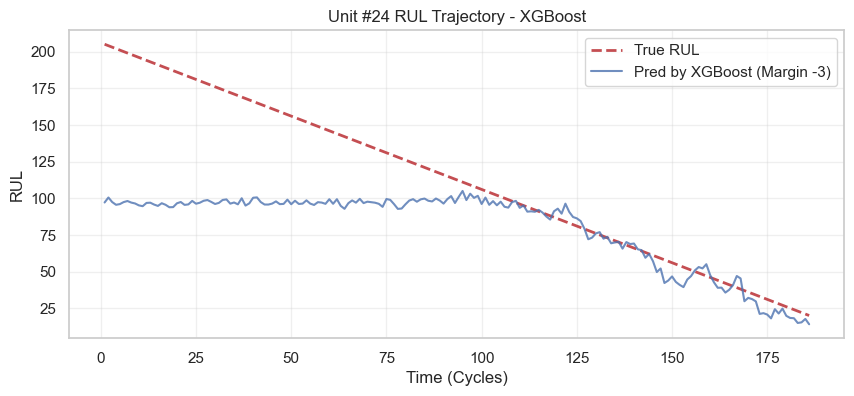

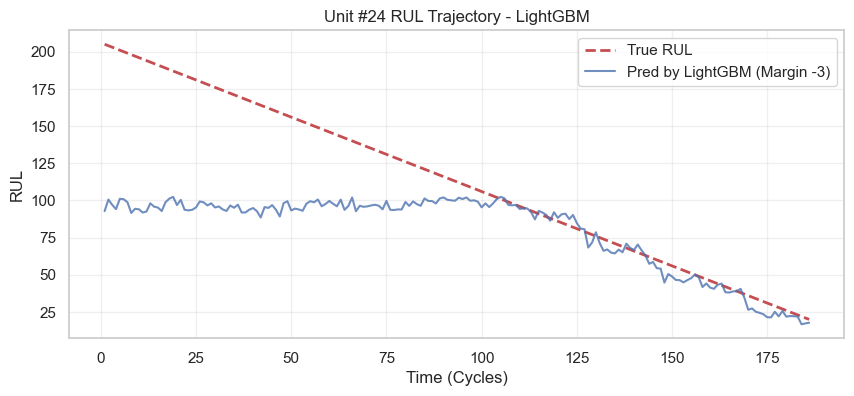

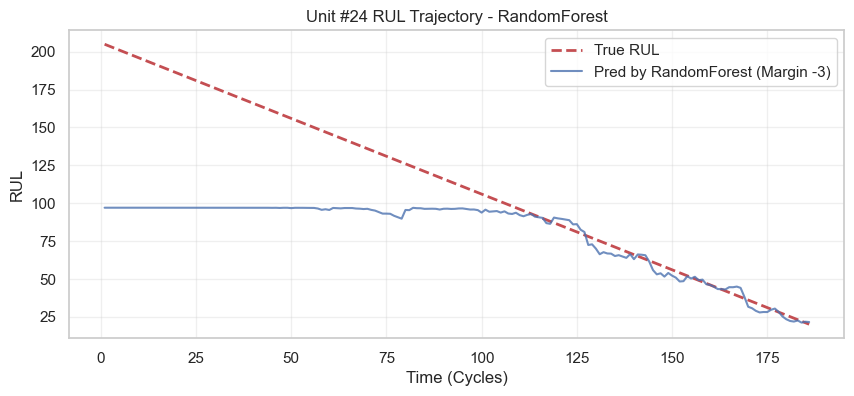

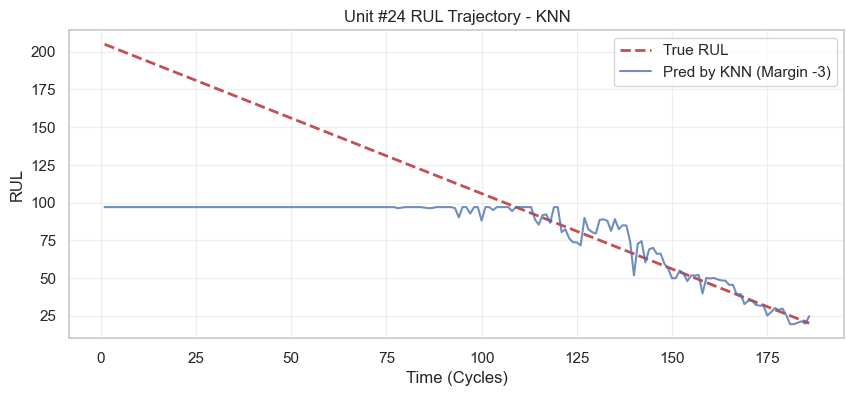

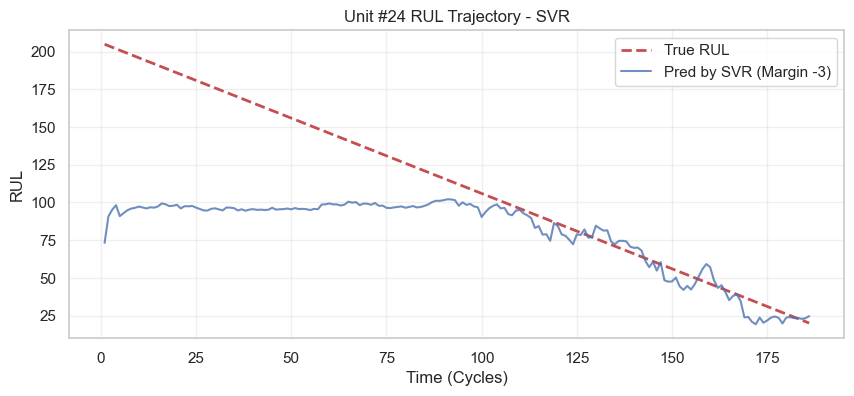

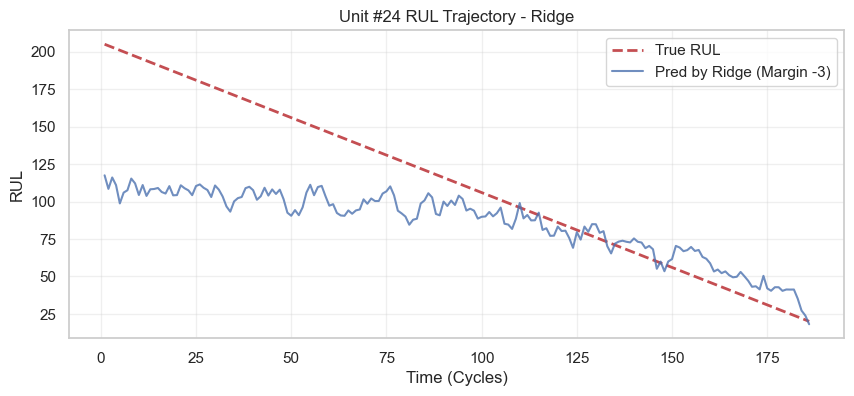

In [33]:
# # [셀 1] available_features 정의
# available_features = [f for f in features if f not in [
#     'WfP3C[pph/psi]', 
#     'WfP3C[pph/psi]_mean_5', 
#     'WfP3C[pph/psi]_std_5', 
#     'WfP3C[pph/psi]_mean_20', 
#     'WfP3C[pph/psi]_std_20'
# ]]
# print(f"✅ 사용 피처: {len(available_features)}개")
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# [수정] Safety Margin이 적용된 v2 시각화 함수
# ---------------------------------------------------------
def plot_engine_trajectory_v2(model_name, pipeline, test_full_df, unit_id, feature_cols):
    engine_data = test_full_df[test_full_df['unit_number'] == unit_id].copy()
    
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    # [중요] 학습에 사용된 피처 순서 그대로 추출
    X_engine = engine_data[feature_cols]
    y_true = engine_data['RUL']
    
    # 예측
    y_pred = pipeline.predict(X_engine)
    
    # 🔧 [Technique C] Safety Margin 적용 (-3)
    # 시각화에서도 점수판과 동일하게 3점 낮춰서 그립니다.
    y_pred = y_pred - 3
    
    y_pred = np.maximum(y_pred, 0) 

    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    # 범례에도 마진 적용 사실 명시
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-', label=f'Pred by {model_name} (Margin -3)', alpha=0.8)
    
    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name}")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 실행 ---
target_unit = 24
all_features = X_train.columns.tolist() 

print(f"🎨 [Visualization] Unit {target_unit} 예측 패턴 확인 (Margin -3 적용됨)")

for name, model in models.items():
    # 파이프라인 구성 (전처리 + 모델)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # [안전장치] 재학습 (Safety Margin의 효과를 정확히 보기 위해)
    pipeline.fit(X_train, y_train)
    
    # 시각화 함수 호출
    plot_engine_trajectory_v2(name, pipeline, test_working, target_unit, all_features)

(1) Life Cycle 시각화: X축(시간)이 흐름에 따라 Y축(수명)이 줄어드는 **기울기(Slope)**를 봐야 합니다.

이상적 예측: 우하향 대각선 (↘)

계단식 예측: 특정 구간에서 모델이 멍청해짐 (ㅡ)

늦은 예측: 실제 수명선보다 위쪽에 그래프가 그려짐 (위험!)

(2) 그래프 해석 방법 (Reader's Guide)
이 그래프를 그리시면 3가지를 체크해야 합니다.

Early Cycle (초기 구간): 그래프가 평평하다가 갑자기 떨어지는가?

의미: RUL Clipping(125) 효과가 잘 먹혔는지 확인. 초기에 너무 출렁거리면 노이즈를 학습한 것임.

Near Failure (고장 직전 구간 - RUL < 30): 예측선이 실제선(True)과 딱 붙어 있는가?

의미: 여기가 제일 중요합니다. 여기서 예측값이 실제보다 높으면(Over-estimation) 정비 시기를 놓칩니다.

Tail Noise (끝부분): 실제 RUL은 0인데 예측값은 10~20에 머물러 있는가?

의미: 모델이 "설마 지금 당장 고장 나겠어?"라고 보수적으로 판단하는 경향이 있는지 파악.

## Autogluon Best-quality 모델 
pc의 성능을 극대화하기 위해 GPU와 cpu의 p-코어 만을 사용. e-코어는 병목

In [34]:
# # [Phase 2 전에 실행] 누락 피처 더미 추가
# missing_cols = ['WfP3C[pph/psi]', 'WfP3C[pph/psi]_mean_5', 'WfP3C[pph/psi]_std_5', 
#                 'WfP3C[pph/psi]_mean_20', 'WfP3C[pph/psi]_std_20']
# for col in missing_cols:
#     if col not in test_working.columns:
#         test_working[col] = 0

In [35]:
from autogluon.tabular import TabularPredictor
import pandas as pd
import torch  # GPU 확인용

# =========================================================
# 🚀 [Phase 2] AutoGluon: GPU + P-Core 최적화 & Best Quality
# =========================================================

print(f"🔥 GPU 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 감지된 GPU: {torch.cuda.get_device_name(0)}")

# ---------------------------------------------------------
# 1. AutoGluon용 데이터셋 준비 (DataFrame 형태)
# ---------------------------------------------------------
# AutoGluon은 스케일링 되지 않은 '원본 데이터'를 선호합니다. (Phase 1의 Pipeline과 다름)

# (1) 학습 데이터 (Train)
train_data_ag = X_train.copy()
train_data_ag['RUL'] = y_train

# (2) 검증 데이터 (Validation) - use_bag_holdout을 위해 필수
val_data_ag = X_val.copy()
val_data_ag['RUL'] = y_val

# (3) 테스트 데이터 (Test) - 최종 평가용
test_data_ag = X_test.copy()
test_data_ag['RUL'] = y_test

print(f"학습 데이터: {train_data_ag.shape}")
print(f"검증 데이터: {val_data_ag.shape}")

# ---------------------------------------------------------
# 2. AutoGluon 학습 (최적화 옵션 적용)
# ---------------------------------------------------------

# 예측기 초기화
predictor = TabularPredictor(
    label='RUL', 
    eval_metric='root_mean_squared_error', # 평가는 RMSE 기준
    problem_type='regression',             # 회귀 문제 명시
    path='ag_models_best_quality'          # 모델 저장 경로
)

# 학습 시작 (사용자 요청 하드웨어 최적화 반영)
predictor.fit(
    train_data=train_data_ag,
    tuning_data=val_data_ag,       # 별도의 검증 데이터 지정
    
    # [핵심 전략] 검증 데이터(tuning_data)를 섞지 않고 별도로 유지하며 배깅 수행
    # (일반적인 K-Fold보다 검증 신뢰도가 높고, Overfitting을 강력하게 방지함)
    use_bag_holdout=True,    
    
    presets='best_quality',        # 최고 성능 모드 (Bagging + Stacking 자동 적용)
    time_limit=600,                # 10분 (GPU 가속 덕분에 충분함)
    
    # [하드웨어 최적화]
    num_gpus=1,                    # RTX 4070 Super 활성화 (CatBoost, NeuralNet 가속)
    num_cpus=16,                   # i9-13900K P-코어 개수에 맞춰 스레드 제한 (E-코어 간섭 방지)
    
    verbosity=2
)

# ---------------------------------------------------------
# 3. 결과 평가 및 리더보드 확인
# ---------------------------------------------------------

print("\n📊 [Phase 2] AutoGluon 리더보드 (검증 데이터 기준)")
# 검증 데이터(val_data_ag)에 대한 성능 순위 확인
lb = predictor.leaderboard(val_data_ag, silent=True)
print(lb[['model', 'score_test', 'score_val', 'pred_time_test']].head(10))

print("\n🏆 [Phase 2] 최종 테스트(Test) 데이터 평가")
# X_test에 대한 최종 성능 측정
perf = predictor.evaluate(test_data_ag)
print(f"실전 테스트 RMSE: {perf['root_mean_squared_error']:.4f}")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          32
Pytorch Version:    2.6.0+cu124
CUDA Version:       12.4
GPU Memory:         GPU 0: 11.99/11.99 GB
Total GPU Memory:   Free: 11.99 GB, Allocated: 0.00 GB, Total: 11.99 GB
GPU Count:          1
Memory Avail:       101.58 GB / 127.76 GB (79.5%)
Disk Space Avail:   828.86 GB / 1861.70 GB (44.5%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1


🔥 GPU 사용 가능 여부: True
🔥 감지된 GPU: NVIDIA GeForce RTX 4070 SUPER
학습 데이터: (16481, 50)
검증 데이터: (4050, 50)


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "c:\Users\user\github\EST_15th_NASA\한지형\ag_models_best_quality"
Train Data Rows:    16481
Train Data Columns: 49
Tuning Data Rows:    4050
Tuning Data Columns: 49
Label Column:       RUL
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    104018.52 MB
	Train Data (Original)  Memory Usage: 7.68 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in or


📊 [Phase 2] AutoGluon 리더보드 (검증 데이터 기준)
                    model  score_test  score_val  pred_time_test
0     WeightedEnsemble_L2   -9.009081  -9.009081        0.891890
1     WeightedEnsemble_L3   -9.009735  -9.009735        5.056276
2         CatBoost_BAG_L2   -9.355622  -9.355622        5.044875
3    ExtraTreesMSE_BAG_L1   -9.368698  -9.368698        0.256238
4         CatBoost_BAG_L1   -9.433783  -9.433783        0.245877
5         LightGBM_BAG_L2   -9.437642  -9.437642        6.776442
6       LightGBMXT_BAG_L2   -9.494353  -9.494353        6.802129
7  NeuralNetFastAI_BAG_L1   -9.526439  -9.526439        0.376822
8    ExtraTreesMSE_BAG_L2   -9.532379  -9.532379        5.129617
9  RandomForestMSE_BAG_L2   -9.620277  -9.620277        5.125398

🏆 [Phase 2] 최종 테스트(Test) 데이터 평가
실전 테스트 RMSE: -20.8463


🎨 [Phase 2] AutoGluon의 Unit 24 예측 패턴 시각화


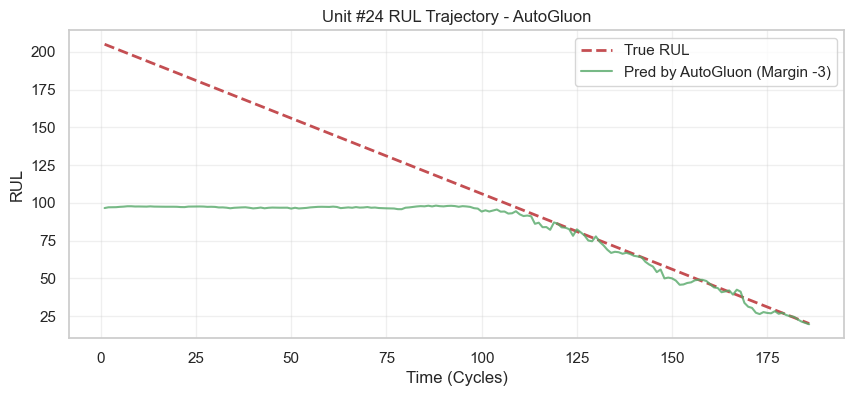

In [36]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# [Phase 2] AutoGluon 시각화 (Safety Margin -3 적용)
# ---------------------------------------------------------
print(f"🎨 [Phase 2] AutoGluon의 Unit {target_unit} 예측 패턴 시각화")

# 1. 해당 유닛 데이터 추출
# (test_working은 위에서 만든 '시각화용 데이터'입니다)
engine_data = test_working[test_working['unit_number'] == target_unit].copy()

# 2. AutoGluon 예측
# AutoGluon은 DataFrame을 통째로 넣으면 학습 때 쓴 컬럼을 알아서 찾아 씁니다.
y_pred_ag = predictor.predict(engine_data)

# 🛠️ [Technique C] Safety Margin 적용 (-3)
# AutoGluon 예측값에도 똑같이 마진을 적용해야 점수판과 일치합니다.
y_pred_ag = y_pred_ag - 3
y_pred_ag = np.maximum(y_pred_ag, 0) # 음수 보정

# 3. 그래프 그리기
plt.figure(figsize=(10, 4))
plt.plot(engine_data['time_in_cycles'], engine_data['RUL'], 'r--', label='True RUL', linewidth=2)
plt.plot(engine_data['time_in_cycles'], y_pred_ag, 'g-', label='Pred by AutoGluon (Margin -3)', alpha=0.8)

plt.title(f"Unit #{target_unit} RUL Trajectory - AutoGluon")
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* 기존 모델  k-fold 앙상블

> k-fold 방식으로 가중치 최적화

Stacking(weighted ensemble) 방식 사용 / OOF (out of fold) stacking : 최적화를 통해 구한 가중치를 기반으로 voting, oof 방식으로 과적합 방식.

> IEEE 가이드인 Damage Propagation Modeling에서 추천한 scoring 방식 사용

* Asymmetric Scoring(비대칭 점수): 항공 엔진 유지보수에서는 **"고장을 예측하지 못하고 지나치는 것(Late Prediction)"**이 **"너무 일찍 경고하는 것(Early Prediction)"**보다 훨씬 비용이 크고 위험합니다.    
그래서 NASA는 늦은 예측에 더 가혹한 벌점을 주는 이 점수 방식을 사용

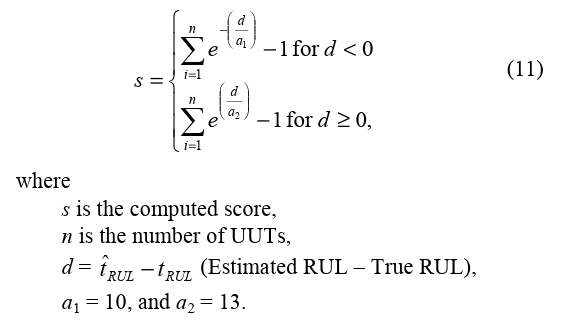

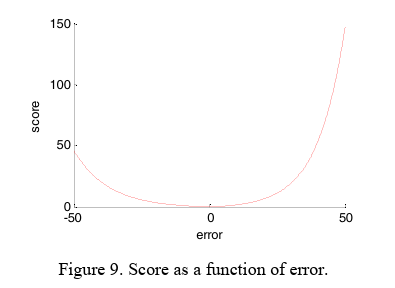

In [37]:
# Asymmetric Scoring 함수 정의

import numpy as np
import matplotlib.pyplot as plt

def nasa_scoring_function(y_true, y_pred):
    """
    NASA C-MAPSS Asymmetric Scoring Function
    - Late Prediction (d > 0): Penalty grows fast (a2 = 10)
    - Early Prediction (d < 0): Penalty grows slower (a1 = 13)
    """
    d = y_pred - y_true
    # 벡터화 연산 (빠른 계산)
    scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(scores)

In [38]:
from scipy.optimize import minimize
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. 데이터 및 변수 준비
# =========================================================
print("\n🚀 [Phase 3] K-Fold 기반 앙상블 가중치 최적화 시작...")

# 전체 데이터 정의 (Train 전체)
full_X = train_df.drop(columns=['unit_number', 'RUL'] + [c for c in train_df.columns if c not in X_train.columns])
full_y = train_df['RUL']

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 모델별 예측값을 저장할 리스트 (Train용, Test용)
# Train용은 가중치 찾는 용도, Test용은 최종 제출 용도
oof_preds_list = []   # Out-Of-Fold Predictions (학습 데이터 전체에 대한 예측)
test_preds_list = []  # X_test에 대한 예측

# 튜닝된 모델 이름 목록 (Phase 1의 models 딕셔너리 사용)
# AutoGluon은 별도 처리하거나 제외 (여기서는 sklearn 호환 모델만 사용)
target_model_names = list(models.keys()) 

# =========================================================
# 2. 각 모델별 K-Fold 예측 수행 (데이터 모으기)
# =========================================================
for name in target_model_names:
    model = models[name]
    
    # 파이프라인 생성
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    print(f"🔄 {name}: K-Fold 예측 데이터 생성 중...", end=" ")
    
    # 1) Train 데이터에 대한 OOF 예측 (가중치 학습용)
    # cross_val_predict는 교차 검증을 통해 전체 데이터에 대한 예측값을 생성합니다.
    oof_pred = cross_val_predict(pipeline, full_X, full_y, cv=kf, n_jobs=-1)
    # 음수 보정
    oof_pred = np.maximum(oof_pred, 0)
    oof_preds_list.append(oof_pred)
    
    # 2) Test 데이터에 대한 예측 (최종 평가용)
    # 전체 데이터로 한 번 더 학습 후 Test 예측
    pipeline.fit(full_X, full_y)
    test_pred = pipeline.predict(X_test)
    test_pred = np.maximum(test_pred, 0)
    test_preds_list.append(test_pred)
    
    rmse = np.sqrt(mean_squared_error(full_y, oof_pred))
    print(f"완료 (RMSE: {rmse:.4f})")

# =========================================================
# 3. 가중치 최적화 (scipy.minimize)
# =========================================================
print("\n⚖️ 최적의 앙상블 가중치 탐색 중...")

def ensemble_objective(weights, predictions, y_true):
    # 가중치 적용 예측
    final_pred = np.zeros_like(predictions[0])
    for w, pred in zip(weights, predictions):
        final_pred += w * pred
    
    # RMSE 최소화 목표
    return np.sqrt(mean_squared_error(y_true, final_pred))

# 초기 가중치 (1/N)
n_models = len(oof_preds_list)
init_weights = [1/n_models] * n_models

# 제약조건 (합 = 1, 0 <= 가중치 <= 1)
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1)] * n_models

# 최적화 실행
res = minimize(ensemble_objective, 
               init_weights, 
               args=(oof_preds_list, full_y), 
               method='SLSQP', 
               bounds=bounds, 
               constraints=constraints)

best_weights = res.x

print("-" * 50)
print("🏆 최적 가중치 발견!")
for name, w in zip(target_model_names, best_weights):
    print(f"   • {name}: {w:.4f}")
print("-" * 50)

# =========================================================
# 4. 최종 앙상블 결과 평가 (Weighted Ensemble)
# =========================================================

# Test 데이터에 가중치 적용
final_ensemble_pred = np.zeros_like(test_preds_list[0])
for w, pred in zip(best_weights, test_preds_list):
    final_ensemble_pred += w * pred

# 성능 평가
y_test_vals = y_test.values
final_rmse = np.sqrt(mean_squared_error(y_test_vals, final_ensemble_pred))
final_rmsle = np.sqrt(mean_squared_log_error(y_test_vals, final_ensemble_pred))
final_r2 = r2_score(y_test_vals, final_ensemble_pred)
final_nasa = nasa_scoring_function(y_test_vals, final_ensemble_pred)

print(f"\n🚀 [Phase 3 Final] 가중치 앙상블 결과 (Test Set)")
print(f"   • RMSE : {final_rmse:.4f}")
print(f"   • RMSLE: {final_rmsle:.4f}")
print(f"   • R2   : {final_r2:.4f}")
print(f"   • NASA Score: {final_nasa:,.2f}")


🚀 [Phase 3] K-Fold 기반 앙상블 가중치 최적화 시작...
🔄 XGBoost: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 5.0469)
🔄 LightGBM: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 5.2837)
🔄 RandomForest: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 6.1578)
🔄 KNN: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 3.9432)
🔄 SVR: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 7.8122)
🔄 Ridge: K-Fold 예측 데이터 생성 중... 완료 (RMSE: 12.5839)

⚖️ 최적의 앙상블 가중치 탐색 중...
--------------------------------------------------
🏆 최적 가중치 발견!
   • XGBoost: 0.1538
   • LightGBM: 0.0007
   • RandomForest: 0.1532
   • KNN: 0.6923
   • SVR: 0.0000
   • Ridge: 0.0000
--------------------------------------------------

🚀 [Phase 3 Final] 가중치 앙상블 결과 (Test Set)
   • RMSE : 21.3778
   • RMSLE: 0.3057
   • R2   : 0.7354
   • NASA Score: 869.36


🎨 [Phase 3] 최종 앙상블(Weighted Ensemble) Unit 24 예측
⚠️ 가중치 개수(6)와 모델 개수(7)가 달라 평균을 사용합니다.


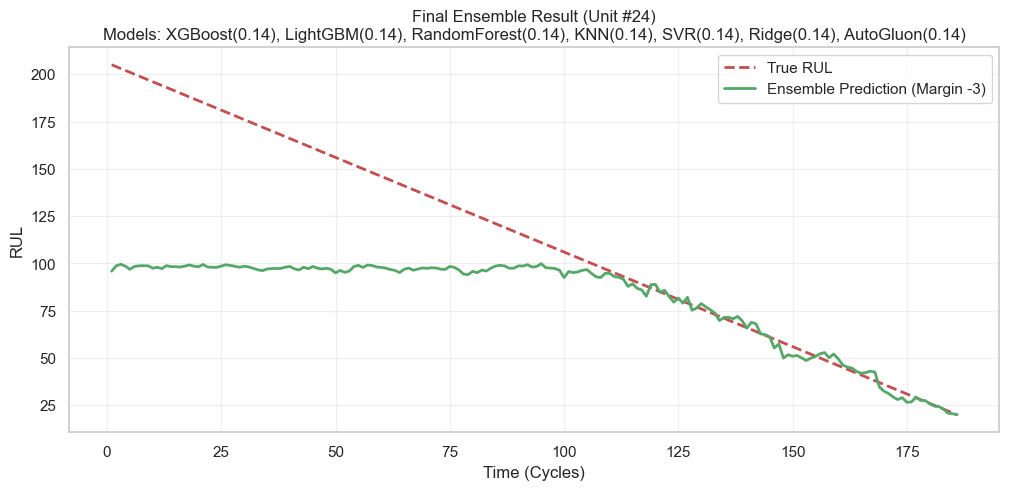

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# [Phase 3] 최종 앙상블 시각화 (Safety Margin -3 적용)
# ---------------------------------------------------------
print(f"🎨 [Phase 3] 최종 앙상블(Weighted Ensemble) Unit {target_unit} 예측")

# 1. 개별 모델 예측값 수집
preds_dict = {}
# 학습에 사용된 컬럼 리스트 (시각화용 데이터에서도 이 컬럼만 뽑아서 씀)
feature_cols = X_train.columns.tolist() 

# (1) Scikit-learn Pipeline 모델 예측 (Ridge, SVR, XGB 등)
for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # [안전장치] 재학습 (Safety Margin 효과를 정확히 보기 위해)
    try:
        pipeline.fit(X_train, y_train) 
        
        # 해당 유닛 데이터 추출
        engine_data = test_working[test_working['unit_number'] == target_unit]
        X_engine = engine_data[feature_cols]
        
        preds_dict[name] = pipeline.predict(X_engine)
    except Exception as e:
        print(f"⚠️ {name} 예측 실패: {e}")

# (2) AutoGluon 예측
try:
    engine_data = test_working[test_working['unit_number'] == target_unit]
    preds_dict['AutoGluon'] = predictor.predict(engine_data)
except Exception as e:
    print(f"⚠️ AutoGluon 예측 실패: {e}")

# 2. 가중치 적용 및 앙상블 (에러 수정 파트)
# ---------------------------------------------------------
# 1) best_weights가 없으면 생성
if 'best_weights' not in locals():
    print("⚠️ best_weights가 없어 평균(Equal Weight)으로 계산합니다.")
    best_weights = np.ones(len(preds_dict)) / len(preds_dict) # 배열로 초기화

# 2) 모델 순서 정의 (학습할 때와 동일한 순서라고 가정)
# 순서: models에 있는 것들 + AutoGluon
model_order = list(models.keys())
if 'AutoGluon' in preds_dict:
    model_order.append('AutoGluon')

# 3) best_weights가 배열(numpy array)인 경우 -> 딕셔너리로 변환
if not isinstance(best_weights, dict):
    # 배열의 길이와 모델 개수가 다르면 (혹시 모를 상황 대비)
    if len(best_weights) != len(model_order):
        print(f"⚠️ 가중치 개수({len(best_weights)})와 모델 개수({len(model_order)})가 달라 평균을 사용합니다.")
        best_weights_dict = {m: 1.0/len(model_order) for m in model_order}
    else:
        # 배열을 딕셔너리로 매핑 ({'Ridge': 0.1, ...})
        best_weights_dict = dict(zip(model_order, best_weights))
else:
    # 이미 딕셔너리라면 그대로 사용
    best_weights_dict = best_weights

# ---------------------------------------------------------

final_pred = np.zeros(len(engine_data))
used_models = []

for model_name, weight in best_weights_dict.items():
    if model_name in preds_dict:
        # 가중치가 0.01보다 큰 모델만 라벨에 표시 (너무 작은건 생략)
        if weight > 0.01:
            used_models.append(f"{model_name}({weight:.2f})")
            
        final_pred += weight * preds_dict[model_name]

# 🛠️ [Technique C] Safety Margin 적용 (-3)
final_pred = final_pred - 3
final_pred = np.maximum(final_pred, 0) # 음수 보정

# 3. 그래프 그리기
plt.figure(figsize=(12, 5))
plt.plot(engine_data['time_in_cycles'], engine_data['RUL'], 'r--', label='True RUL', linewidth=2)
# 범례에 Margin 적용 사실 명시
plt.plot(engine_data['time_in_cycles'], final_pred, 'g-', label='Ensemble Prediction (Margin -3)', linewidth=2)

plt.title(f"Final Ensemble Result (Unit #{target_unit})\nModels: {', '.join(used_models)}")
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 결과 비교

In [40]:
print("📊 results_df 확인:")
print(results_df)
print("\n" + "="*50)
print("📊 results_df 통계:")
print(results_df.describe())
print("\n" + "="*50)
print("극단값 확인 (RMSLE > 1):")
print(results_df[results_df['RMSLE'] > 1])

📊 results_df 확인:
               NASA Score       RMSE     RMSLE        MAE        R2
Model                                                              
XGBoost        786.201805  22.570451  0.425615  16.712011  0.705001
LightGBM       836.171154  22.442142  0.408738  16.325400  0.708345
RandomForest   894.790183  22.930192  0.371073  17.100618  0.695522
KNN           1362.685271  24.197084  0.414709  18.335611  0.660948
SVR            567.578689  20.072753  0.280278  14.947013  0.766679
Ridge          840.906268  23.144477  0.513573  17.876656  0.689805

📊 results_df 통계:
        NASA Score       RMSE     RMSLE        MAE        R2
count     6.000000   6.000000  6.000000   6.000000  6.000000
mean    881.388895  22.559516  0.402331  16.882885  0.704383
std     261.933851   1.368144  0.076138   1.202746  0.034855
min     567.578689  20.072753  0.280278  14.947013  0.660948
25%     798.694142  22.474219  0.380489  16.422053  0.691234
50%     838.538711  22.750321  0.411723  16.906315  0.7

📊 시각화 데이터 (LinearReg 제외):
               NASA Score       RMSE     RMSLE        MAE        R2
XGBoost        786.201805  22.570451  0.425615  16.712011  0.705001
LightGBM       836.171154  22.442142  0.408738  16.325400  0.708345
RandomForest   894.790183  22.930192  0.371073  17.100618  0.695522
KNN           1362.685271  24.197084  0.414709  18.335611  0.660948
SVR            567.578689  20.072753  0.280278  14.947013  0.766679
Ridge          840.906268  23.144477  0.513573  17.876656  0.689805
AutoGluon             NaN  20.846294  0.289827  15.017639  0.748349


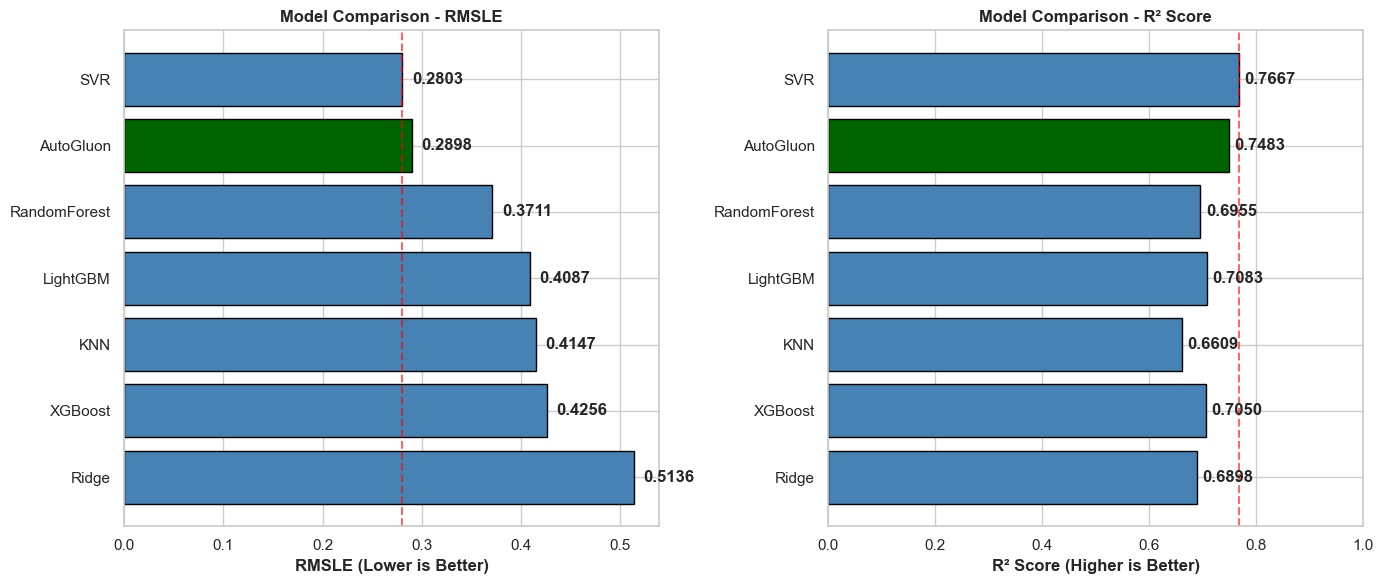


🏆 최종 승자: SVR
   RMSLE: 0.2803
   R2: 0.7667

📋 전체 순위 (RMSLE 기준):
                 RMSLE        R2
SVR           0.280278  0.766679
AutoGluon     0.289827  0.748349
RandomForest  0.371073  0.695522
LightGBM      0.408738  0.708345
KNN           0.414709  0.660948
XGBoost       0.425615  0.705001
Ridge         0.513573  0.689805


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_log_error, r2_score, mean_squared_error, mean_absolute_error

# 1. 데이터 준비 
final_df = results_df.copy()

# 2. AutoGluon 추가
ag_pred = predictor.predict(test_data_ag)
ag_pred_clipped = np.maximum(ag_pred, 1e-6)
y_test_clipped = np.maximum(y_test.values, 1e-6)

ag_rmse = np.sqrt(mean_squared_error(y_test, ag_pred))
ag_rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, ag_pred_clipped))
ag_mae = mean_absolute_error(y_test, ag_pred)
ag_r2 = r2_score(y_test, ag_pred)

ag_row = pd.DataFrame([{
    'RMSE': ag_rmse, 
    'RMSLE': ag_rmsle, 
    'MAE': ag_mae, 
    'R2': ag_r2
}], index=['AutoGluon'])

final_df = pd.concat([final_df, ag_row])

print("📊 시각화 데이터 (LinearReg 제외):")
print(final_df)

# 3. 시각화
final_df = final_df.sort_values('RMSLE', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 색상 설정
colors = ['darkgreen' if 'AutoGluon' in str(idx) else 'steelblue' for idx in final_df.index]

# RMSLE 그래프
axes[0].barh(final_df.index, final_df['RMSLE'], color=colors, edgecolor='black')
axes[0].set_xlabel('RMSLE (Lower is Better)', fontweight='bold')
axes[0].set_title('Model Comparison - RMSLE', fontweight='bold')
axes[0].axvline(x=final_df['RMSLE'].min(), color='red', linestyle='--', alpha=0.6)

for i, (idx, val) in enumerate(final_df['RMSLE'].items()):
    axes[0].text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold')

# R2 그래프
axes[1].barh(final_df.index, final_df['R2'], color=colors, edgecolor='black')
axes[1].set_xlabel('R² Score (Higher is Better)', fontweight='bold')
axes[1].set_title('Model Comparison - R² Score', fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].axvline(x=final_df['R2'].max(), color='red', linestyle='--', alpha=0.6)

for i, (idx, val) in enumerate(final_df['R2'].items()):
    axes[1].text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 결론
best_model = final_df['RMSLE'].idxmin()
print(f"\n🏆 최종 승자: {best_model}")
print(f"   RMSLE: {final_df.loc[best_model, 'RMSLE']:.4f}")
print(f"   R2: {final_df.loc[best_model, 'R2']:.4f}")

print("\n📋 전체 순위 (RMSLE 기준):")
print(final_df.sort_values('RMSLE')[['RMSLE', 'R2']])

🚀 모든 모델에 대해 채점을 시작합니다...
✅ 총 8개 모델 예측 완료!


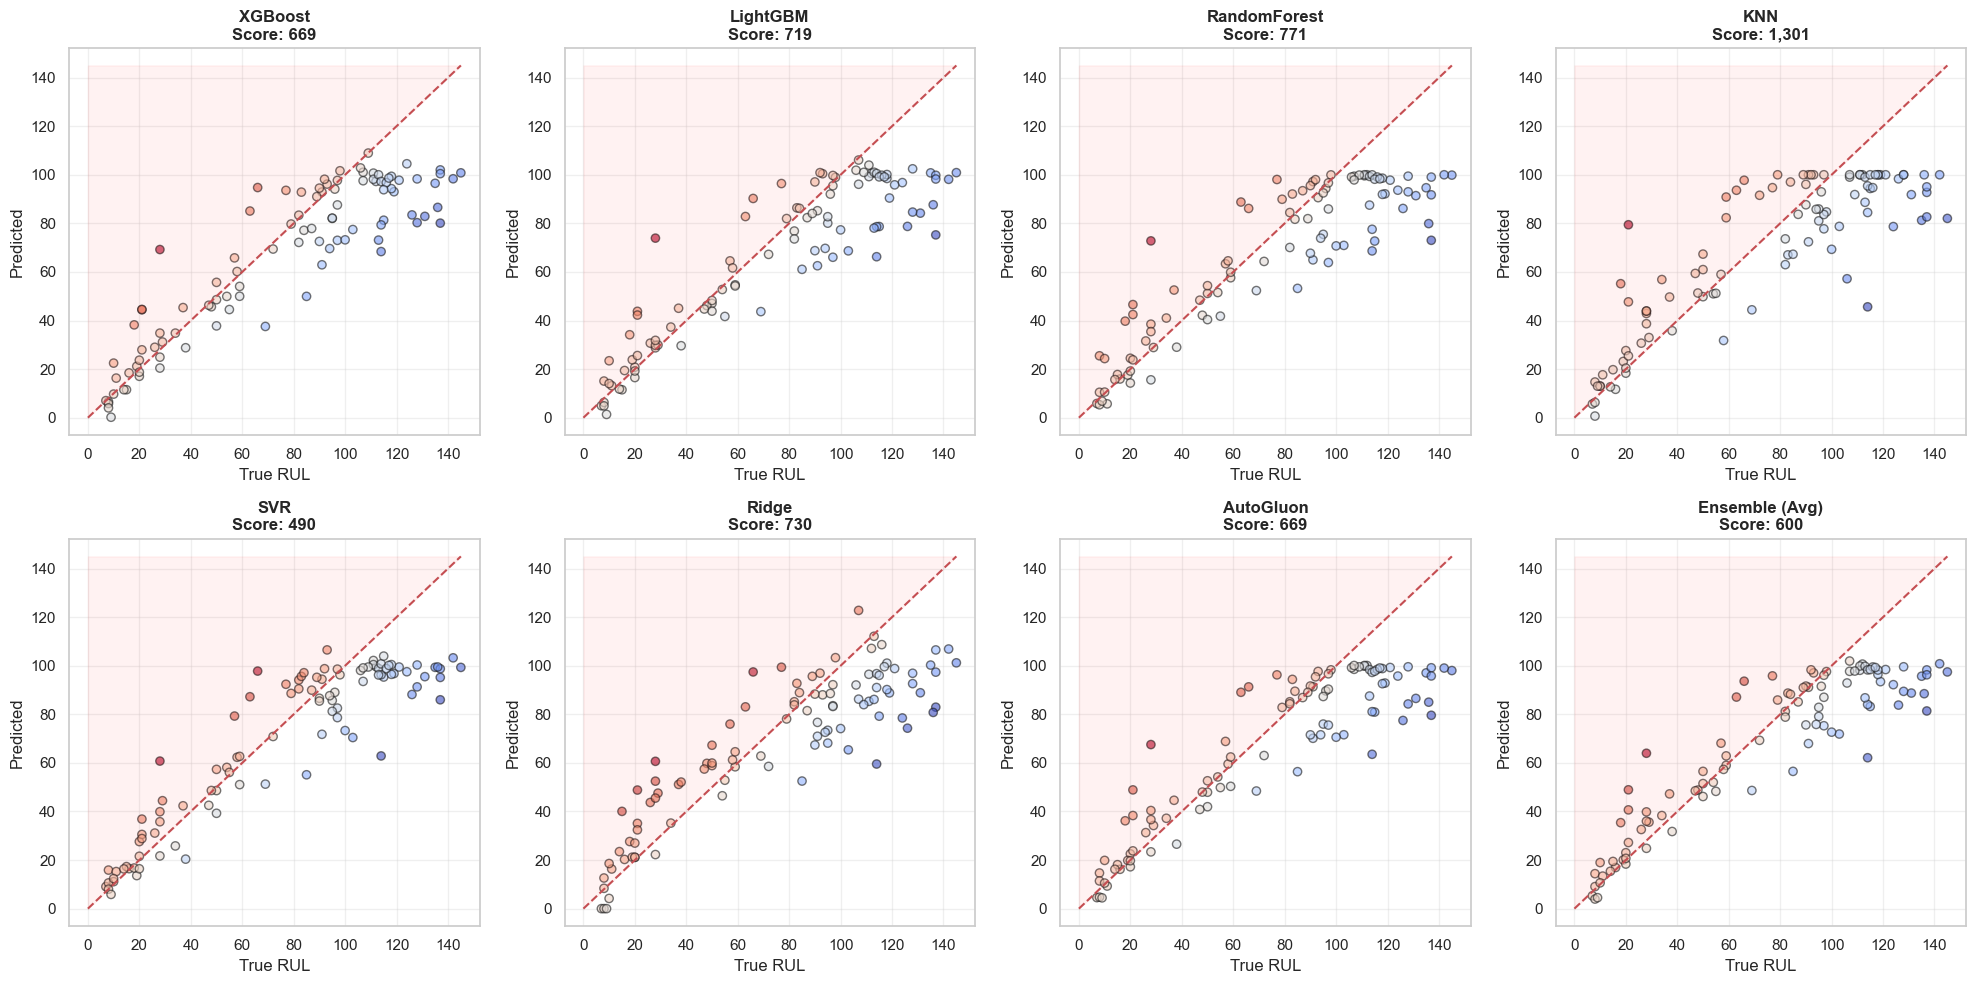


📊 NASA Asymmetric Scoring 최종 순위 (Total 8 Models)
🏆: SVR                  | Score: 489.84
2위: Ensemble (Avg)       | Score: 600.44
3위: XGBoost              | Score: 668.56
4위: AutoGluon            | Score: 669.42
5위: LightGBM             | Score: 719.36
6위: Ridge                | Score: 730.46
7위: RandomForest         | Score: 771.49
8위: KNN                  | Score: 1,300.74


In [42]:
import math

# =========================================================
# 1. 모든 모델의 예측값 확보 (All Predictions)
# =========================================================

all_results = {}
ensemble_preds = [] # 앙상블을 만들기 위해 예측값들을 모아둘 리스트

print("🚀 모든 모델에 대해 채점을 시작합니다...")

# (1) Phase 1의 6개 모델 예측
for name, model in models.items():
    # 파이프라인 재구성 (Imputer -> Scaler -> Model)
    # (주의: 이미 학습된 모델 객체를 사용하므로 fit은 생략 가능하거나, 필요시 재학습)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train) # 안전하게 재학습 (시간이 걸리면 생략 가능)
    
    pred = pipeline.predict(X_test)
    pred = np.maximum(pred, 0) # 음수 보정
    
    all_results[name] = pred
    ensemble_preds.append(pred) # 앙상블용으로 저장

# (2) Phase 2 AutoGluon 예측
ag_pred = predictor.predict(test_data_ag)
ag_pred = np.maximum(ag_pred, 0)
all_results['AutoGluon'] = ag_pred.values # Series -> Array 변환
ensemble_preds.append(ag_pred.values) # 앙상블에 AutoGluon도 포함 (성능 향상 비결!)

# (3) [New] 평균 앙상블 (Simple Averaging Ensemble) 생성
# 위 7개 모델의 예측값을 다 더해서 평균을 냅니다.
avg_ensemble_pred = np.mean(ensemble_preds, axis=0)
all_results['Ensemble (Avg)'] = avg_ensemble_pred

print(f"✅ 총 {len(all_results)}개 모델 예측 완료!")


# =========================================================
# 2. Asymmetric Score 계산 및 시각화 (Dynamic Layout)
# =========================================================

# 그래프 배치 계산 (모델 개수에 맞춰 자동 줄바꿈)
n_models = len(all_results)
n_cols = 4 # 한 줄에 4개씩 그리기
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() # 2차원 배열을 1차원으로 펴서 쓰기 편하게 만듦

final_scores = {}
y_true = y_test.values 

# 반복문으로 그리기
for i, (name, y_pred) in enumerate(all_results.items()):
    ax = axes[i]
    
    # 1. 스코어 계산
    score = nasa_scoring_function(y_true, y_pred)
    final_scores[name] = score
    
    # 2. 산점도 그리기
    diff = y_pred - y_true
    max_val = max(y_true.max(), y_pred.max())
    
    # 색상: Late Prediction(빨강) vs Early Prediction(파랑)
    sc = ax.scatter(y_true, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    
    # 위험 구역(Late Prediction) 표시
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    # 꾸미기
    ax.set_title(f"{name}\nScore: {score:,.0f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

# 남는 빈 그래프 공간 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# =========================================================
# 🏆 최종 순위표 출력
# =========================================================
print("\n" + "="*50)
print(f"📊 NASA Asymmetric Scoring 최종 순위 (Total {n_models} Models)")
print("="*50)

# 점수가 낮은 순서대로 정렬 (낮을수록 좋음)
sorted_scores = sorted(final_scores.items(), key=lambda x: x[1])

for rank, (m, s) in enumerate(sorted_scores, 1):
    prefix = "🏆" if rank == 1 else f"{rank}위"
    print(f"{prefix}: {m:<20} | Score: {s:,.2f}")

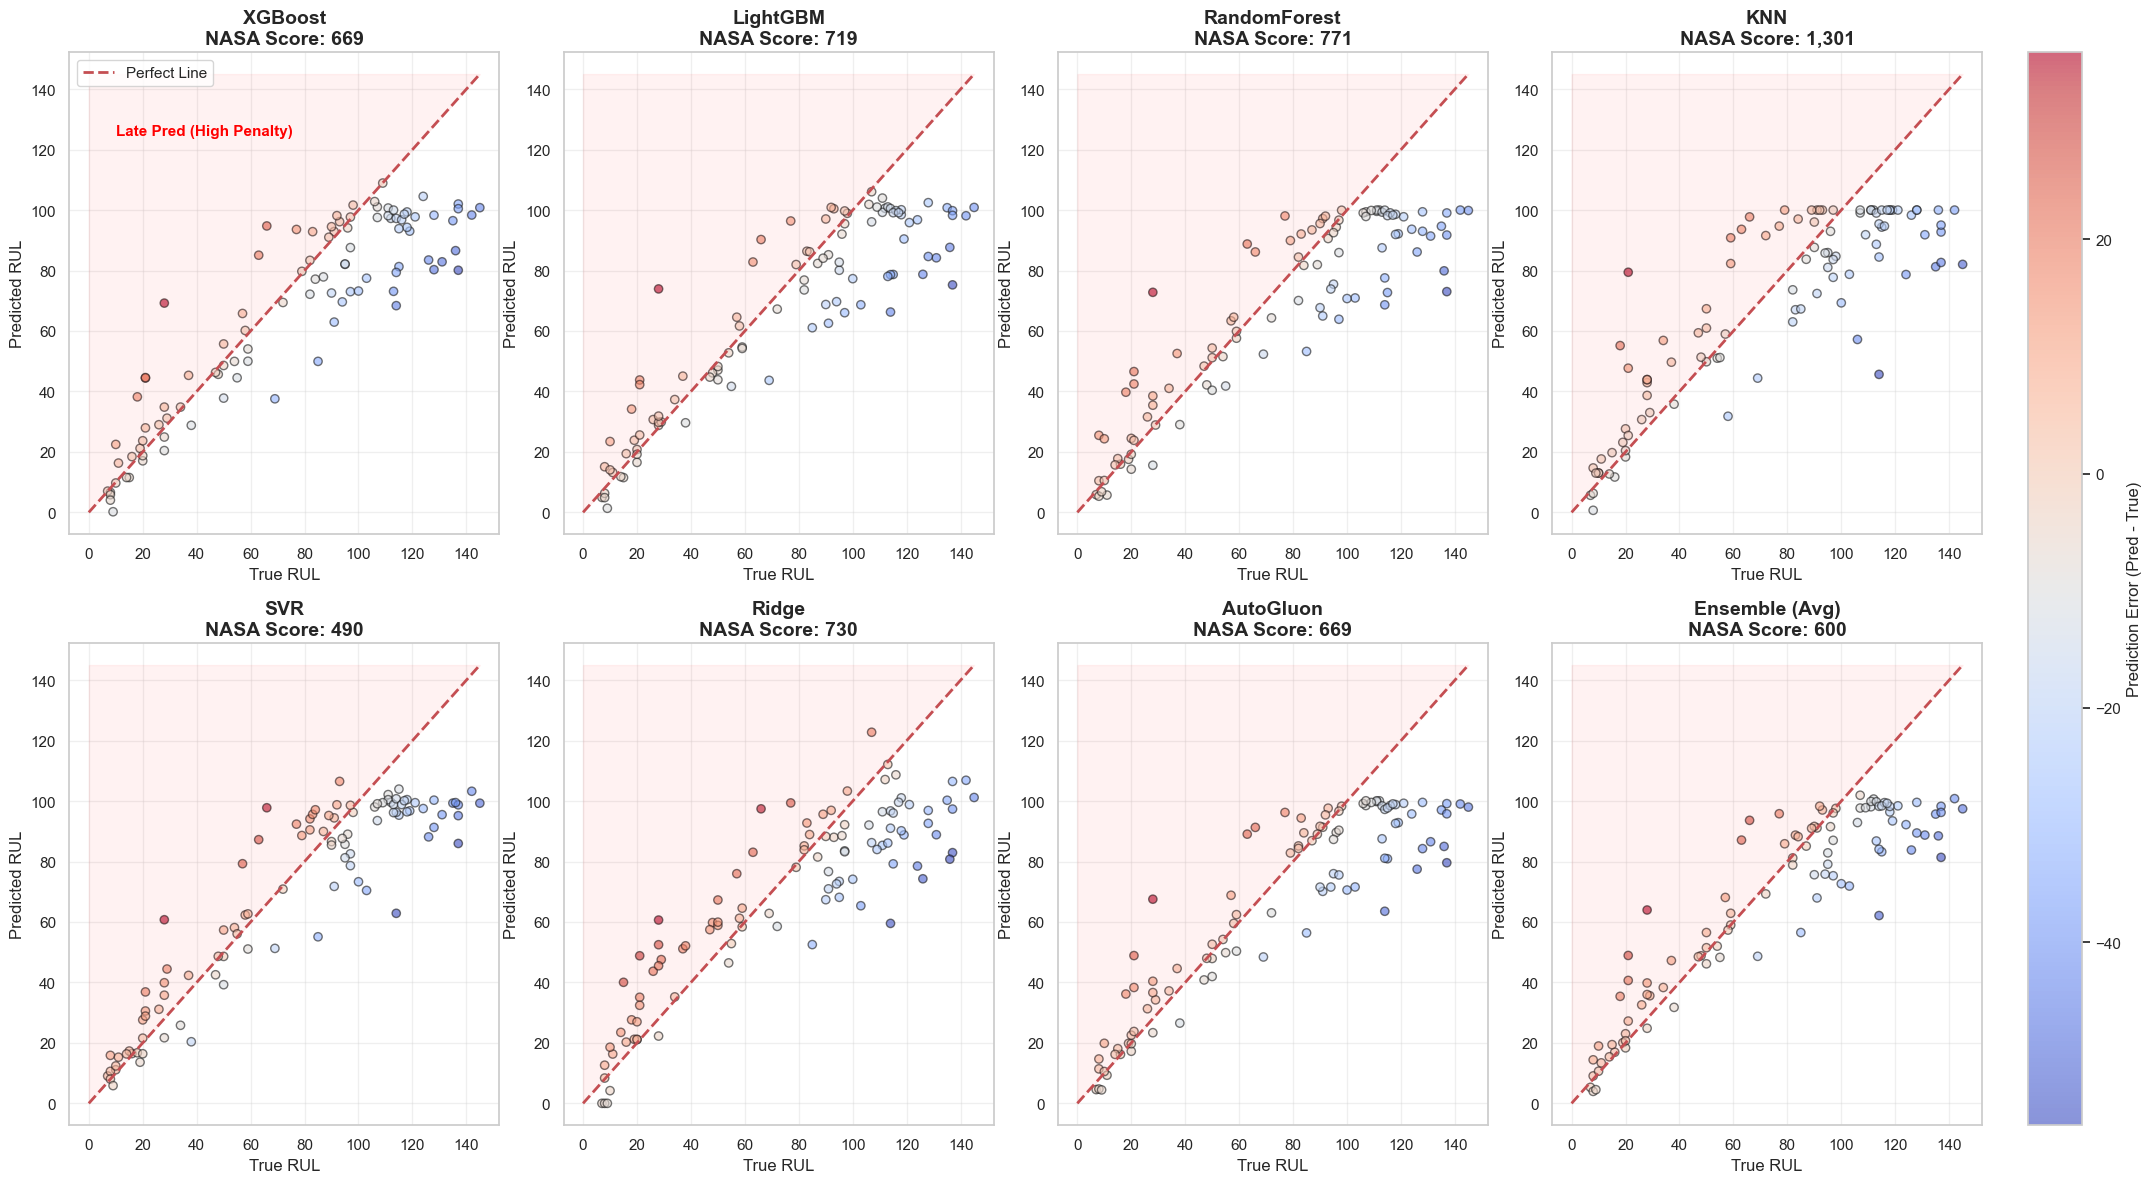


🏆 Asymmetric Scoring 최종 우승 모델: SVR
💎 Score: 489.84 (낮을수록 좋음)

📊 [전체 모델 순위표]
1위 🥇: SVR                       | Score: 489.84
2위 🥈: Ensemble (Avg)            | Score: 600.44
3위 🥉: XGBoost                   | Score: 668.56
4위 : AutoGluon                 | Score: 669.42
5위 : LightGBM                  | Score: 719.36
6위 : Ridge                     | Score: 730.46
7위 : RandomForest              | Score: 771.49
8위 : KNN                       | Score: 1,300.74


In [43]:
import math
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 📈 모든 모델 Asymmetric Score 계산 및 그래프 그리기
# =========================================================

# 1. 그래프 레이아웃 설정 (자동 계산)
n_models = len(all_results)
n_cols = 4  # 한 줄에 4개씩 그리기
n_rows = math.ceil(n_models / n_cols) # 모델 수에 맞춰 행 개수 자동 조절

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = axes.flatten() # 1차원 배열로 펼침 (인덱싱 편의)

final_scores = {}
y_true = y_test.values 

# 2. 모든 모델 반복문 실행
for i, (name, y_pred) in enumerate(all_results.items()):
    ax = axes[i]
    
    # (1) 스코어 계산
    score = nasa_scoring_function(y_true, y_pred)
    final_scores[name] = score
    
    # (2) 오차(Diff) 계산
    diff = y_pred - y_true
    
    # (3) 산점도 그리기 (True vs Pred)
    # 색상: 오차가 클수록(Late Prediction) 빨간색, 작을수록 파란색
    sc = ax.scatter(y_true, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    
    # 기준선 (Perfect Prediction)
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect Line', linewidth=2)
    
    # (4) 꾸미기
    ax.set_title(f"{name}\nNASA Score: {score:,.0f}", fontsize=14, fontweight='bold')
    ax.set_xlabel("True RUL", fontsize=12)
    ax.set_ylabel("Predicted RUL", fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # (5) Asymmetric 영역 표시 (위험 구간 강조)
    # 그래프 상단(예측 > 실제)이 위험 구역
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    # 첫 번째 그래프에만 텍스트 설명 추가 (지저분함 방지)
    if i == 0:
        ax.text(10, max_val-20, "Late Pred (High Penalty)", color='red', fontsize=11, fontweight='bold')
        ax.legend(loc='upper left')

# 3. 남는 빈 그래프 공간 지우기 (모델 개수가 4의 배수가 아닐 때)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. 전체 레이아웃 조정 및 컬러바 추가
plt.tight_layout()
# 모든 서브플롯에 대해 하나의 컬러바 공유
cb = fig.colorbar(sc, ax=axes.ravel().tolist(), pad=0.02)
cb.set_label('Prediction Error (Pred - True)', fontsize=12)
plt.show()

# =========================================================
# 🏆 최종 승자 발표 (전체 모델 대상)
# =========================================================
best_model_name = min(final_scores, key=final_scores.get) # 점수가 낮을수록 좋음
best_score = final_scores[best_model_name]

print("\n" + "="*50)
print(f"🏆 Asymmetric Scoring 최종 우승 모델: {best_model_name}")
print(f"💎 Score: {best_score:,.2f} (낮을수록 좋음)")
print("="*50)

print("\n📊 [전체 모델 순위표]")
# 점수 낮은 순 정렬
sorted_scores = sorted(final_scores.items(), key=lambda x: x[1])
for rank, (m, s) in enumerate(sorted_scores, 1):
    medal = ""
    if rank == 1: medal = "🥇"
    elif rank == 2: medal = "🥈"
    elif rank == 3: medal = "🥉"
    
    print(f"{rank}위 {medal}: {m:<25} | Score: {s:,.2f}")